SWMAL

Assignment 3

Group members: 

Nilas Lorenzen (202307961), Peter Fabiansen (202305295), Rasmus Møller (202305159)

\newpage



# L14 Exercise: CNN Classification - CIFAR-10 dataset
## 1. Import Libraries


In [ ]:
# 1. Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  2


## 2. Load and Inspect the Dataset

In [ ]:
# 2. Load and preprocess the CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(X_train.shape, X_test.shape)


(50000, 32, 32, 3) (10000, 32, 32, 3)


### Class Names

In [ ]:

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

## 3. Visualize Sample Images

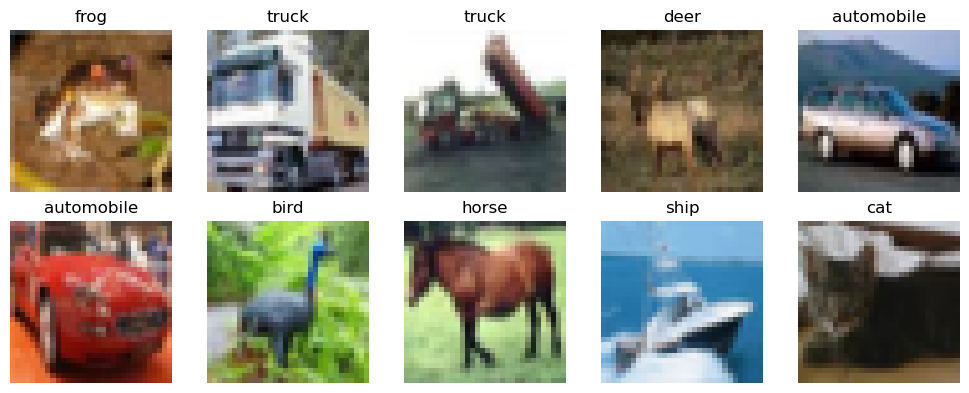

In [ ]:
# 3. Visualize some sample images from the dataset
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.show()


## 4. Build a CNN Model

In [ ]:
# 4. Build a simple CNN model
img_size = (32, 32)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='valid', input_shape=(img_size[0],img_size[1],3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu', padding='valid'),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu', padding='valid'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 15, 15, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 4, 4, 64)          36928     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 2, 2, 64)          0

2026-04-20 08:07:02.608830: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-20 08:07:02.610092: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-20 08:07:02.611309: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

## 5. Train the Model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# T9.b) Introducing early stopping finding minimum val_loss
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    mode='min',               
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train_cat,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/30


2026-04-20 08:07:04.192846: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8800
2026-04-20 08:07:04.915372: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f1af36b9170 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-20 08:07:04.915401: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-04-20 08:07:04.915406: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-04-20 08:07:04.918676: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776665224.979884 2236090 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 [==============================] - 4s 4ms/step - loss: 1.7828 - accuracy: 0.3357 - val_loss: 1.4691 - val_accuracy: 0.4586
Epoch 2/30
625/625 [==============================] - 2s 3ms/step - loss: 1.4067 - accuracy: 0.4918 - val_loss: 1.2608 - val_accuracy: 0.5502
Epoch 3/30
625/625 [==============================] - 2s 2ms/step - loss: 1.2713 - accuracy: 0.5470 - val_loss: 1.1731 - val_accuracy: 0.5818
Epoch 4/30
625/625 [==============================] - 2s 3ms/step - loss: 1.1793 - accuracy: 0.5817 - val_loss: 1.0985 - val_accuracy: 0.6066
Epoch 5/30
625/625 [==============================] - 2s 3ms/step - loss: 1.1037 - accuracy: 0.6101 - val_loss: 1.0235 - val_accuracy: 0.6418
Epoch 6/30
625/625 [==============================] - 2s 3ms/step - loss: 1.0409 - accuracy: 0.6338 - val_loss: 1.0449 - val_accuracy: 0.6329
Epoch 7/30
625/625 [==============================] - 2s 3ms/step - loss: 0.9959 - accuracy: 0.6513 - val_loss: 0.9851 - val_accuracy: 0.6477
Epoch 8/30
625/62

## 6. Evaluate the Model on test dataset

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print("Test accuracy:", test_acc)

y_true = y_test.flatten()

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

313/313 [==============================] - 0s 1ms/step - loss: 0.8794 - accuracy: 0.6963
Test accuracy: 0.6963000297546387
313/313 [==============================] - 0s 721us/step


## 7. Precision, Recall, F1-score

In [ ]:

print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall:", recall_score(y_true, y_pred, average='weighted'))
print("F1:", f1_score(y_true, y_pred, average='weighted'))


Precision: 0.6948660987920396
Recall: 0.6963
F1: 0.692874379980511


## 8. Confusion Matrix

In [ ]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

[[736  21  36  14  32   2   9  11 106  33]
 [ 20 836   1   5   4   3   7   2  48  74]
 [ 79  10 480  72 110  72 102  44  19  12]
 [ 16  16  52 546  68 134  88  37  21  22]
 [ 19   8  44  76 669  11  71  81  14   7]
 [ 12   9  41 225  55 529  38  57  15  19]
 [  4   7  40  67  42   7 802  12   7  12]
 [ 21   5  25  51  63  55  16 734   6  24]
 [ 67  28   5  12   4   3   5   3 843  30]
 [ 36  99   3  12   5   6   5  12  34 788]]


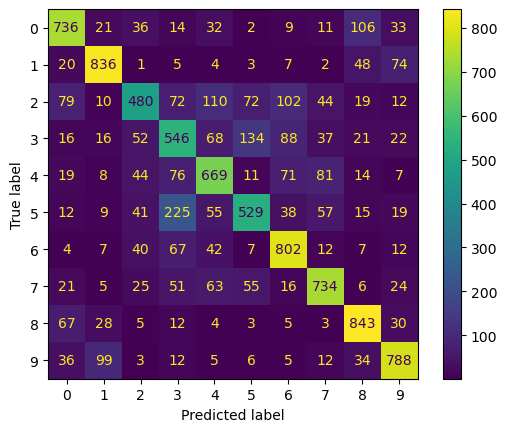

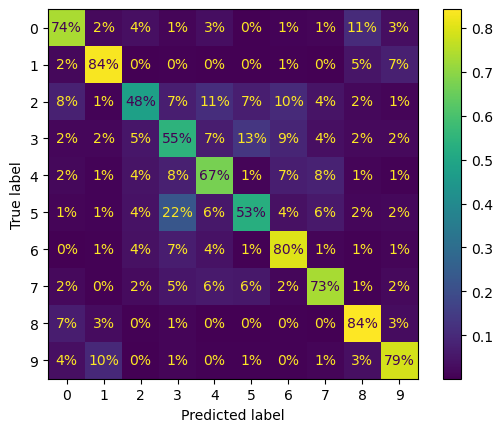

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
plt.show()

ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize="true", values_format=".0%")
plt.show()


## 9. Residual Units

- Q9.a) Does ResidualBlocks improve convergence?\
Yes, that is the point of the skip connection. During backpropergation, the gradient can drecrease to a very small number, meaning that the weights in the early layers wont matter, this would create convergens problems, residual blocks allow the gradient to move past the minimizing weights in the last layers.

- Q9.b) Does ResidualBlocks reduce overfitting?\
No, but this can be done by other methods such as Dropout and batch normalization.

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


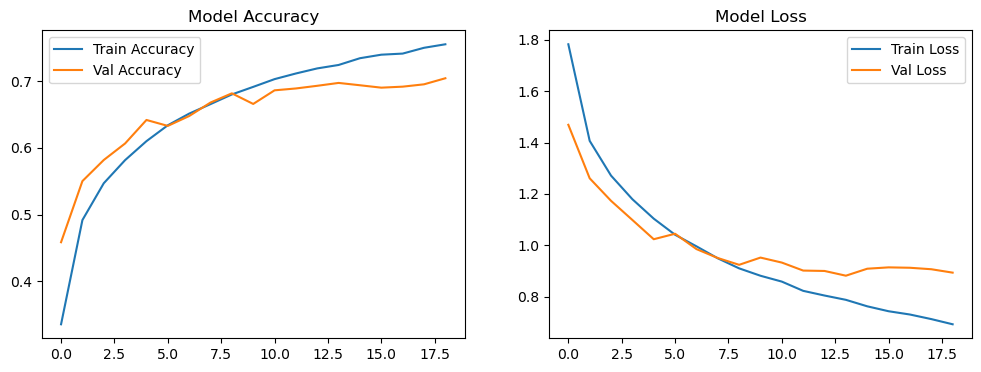

In [ ]:
# T9.a) Plot training history and accuracy curves
import matplotlib.pyplot as plt

print(history.history.keys())

# Plot Training & Validation Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

### Residual Unit Implementation

In [ ]:
from functools import partial
import tensorflow as tf

DefaultConv2D = partial(tf.keras.layers.Conv2D,
                        kernel_size=3,
                        strides=1,
                        padding='same',
                        kernel_initializer='he_normal',
                        use_bias=False)

class ResidualUnit(tf.keras.layers.Layer):
    def __init__(self, filters, strides=1, activation='relu', **kwargs):
        super().__init__(**kwargs)
        self.activation = tf.keras.activations.get(activation)
        self.main_layers = [
            DefaultConv2D(filters, strides=strides),
            tf.keras.layers.BatchNormalization(),
            self.activation,
            DefaultConv2D(filters),
            tf.keras.layers.BatchNormalization()
        ]
        self.skip_layers = []
        if strides > 1:
            self.skip_layers = [
                DefaultConv2D(filters, kernel_size=1, strides=strides),
                tf.keras.layers.BatchNormalization()
            ]

    def call(self, inputs):
        z = inputs
        for layer in self.main_layers:
            z = layer(z)
        skip_z = inputs
        for layer in self.skip_layers:
            skip_z = layer(skip_z)
        return self.activation(z + skip_z)

### Residual units used in a Modified ResNet-34 Model

In [ ]:
model = tf.keras.Sequential([
    DefaultConv2D(64, kernel_size=3, strides=1, input_shape=[32, 32, 3]),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPool2D(pool_size=3, strides=2, padding='same'),
])

# lighter ResNet
prev_filters = 64
for filters in [64]*2 + [128]*2 + [256]*2:
    strides = 1 if filters == prev_filters else 2
    model.add(ResidualUnit(filters, strides=strides))
    prev_filters = filters

model.add(tf.keras.layers.GlobalAveragePooling2D())
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

# optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 32, 32, 64)        1728      
                                                                 
 batch_normalization (Batch  (None, 32, 32, 64)        256       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 32, 32, 64)        0         
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 16, 16, 64)        0         
 g2D)                                                            
                                                                 
 residual_unit (ResidualUni  (None, 16, 16, 64)        74240     
 t)                                                              
                                                      

Epoch 1/50
625/625 [==============================] - 15s 15ms/step - loss: 1.4156 - accuracy: 0.5092 - val_loss: 2.2183 - val_accuracy: 0.3810
Epoch 2/50
625/625 [==============================] - 8s 12ms/step - loss: 0.8952 - accuracy: 0.6892 - val_loss: 1.4616 - val_accuracy: 0.5456
Epoch 3/50
625/625 [==============================] - 8s 12ms/step - loss: 0.6998 - accuracy: 0.7606 - val_loss: 0.8446 - val_accuracy: 0.7212
Epoch 4/50
625/625 [==============================] - 8s 12ms/step - loss: 0.5724 - accuracy: 0.8034 - val_loss: 0.6576 - val_accuracy: 0.7693
Epoch 5/50
625/625 [==============================] - 8s 12ms/step - loss: 0.4682 - accuracy: 0.8407 - val_loss: 0.8430 - val_accuracy: 0.7356
Epoch 6/50
625/625 [==============================] - 8s 12ms/step - loss: 0.3757 - accuracy: 0.8701 - val_loss: 0.7594 - val_accuracy: 0.7572
Epoch 7/50
625/625 [==============================] - 8s 12ms/step - loss: 0.2954 - accuracy: 0.8982 - val_loss: 0.8861 - val_accuracy: 0.745

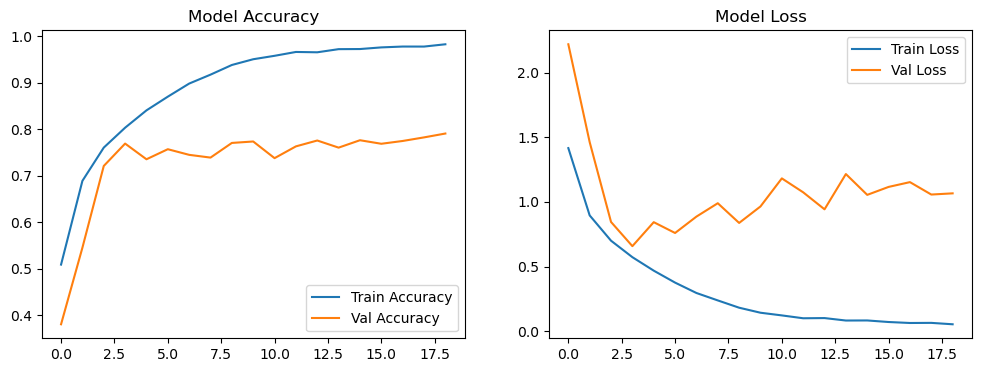

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# trying residual block with GPU cluster
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    mode='min',               
    restore_best_weights=True
)

history2 = model.fit(
    X_train, y_train_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print("Test accuracy:", test_acc)

y_true = y_test.flatten()

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall:", recall_score(y_true, y_pred, average='weighted'))
print("F1:", f1_score(y_true, y_pred, average='weighted'))

# Plot Training & Validation Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.show()


## 10. Questions for reflection

- Q10.a) Show how to find and calculated the 18496 parameters used in the second Conv layer? (Base model without residual units)\
Assuming Padding=same, for easier explaination of the output dimensions. The first convolution has 32 filters which makes the output $x \cdot x \cdot 32$, then a maxpooling reduces the size to $x/2 \cdot x/2 \cdot 32$, then convolution 2 has 64 filters each with a filter of 3x3, this must be done on each of the 32 filters from conv1, making the number of weights needed for this convolution: $(32 \cdot 3 \cdot 3 \cdot 64) =18432$.
The parameters explains the number of training variables. For each filter the the bias term is added making the total parameters: $(32 \cdot 3 \cdot 3 \cdot 64) + 64 =18496$
  
- Q10.b) What happens if padding='same' is changed to 'valid' and what does it means?\
When changing the padding to valid, less information is kept in the corners, here the convolution is only the 3x3 pixels from the photo, when the padding is set to 'same' the input is the same as the output in this case there will be added a zero boundary pixel all the way around, this ensures that more infomation i kept in the convolution. Using padding='same' makes the accuracy a 5% better, but bear in mind that this is only a 32x32 pixel photo, for higher resolution photos the object of interest is most often not in the corners, meaning that the accuracy will most likely be better but not much. Using padding='valid' is computationally lighter, since the pixel of interest is reduced by 2 in the vertical and horizontal dimensions 32x32 -> 30x30.

- Q10.c) Does the residual units improve model accuracy?\
Yes the accuracy is increased by 5%, but i experienced that the validation accuracy and loss fluctuated a lot, this was reduced by using stide=1, and using a lighter resnet version where the convolution with the most filters is 2*265, and the input=[32, 32, 3] to fit the input data from cifar10.


# 15  Exercise: Transfer Learning and Semantic Segmentation

## 1. Datasets (Suggestions)

In [ ]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


## 2. Data Loading and Augmentation

In [ ]:
import kagglehub

# Download latest version
base_path = kagglehub.dataset_download("alessiocorrado99/animals10")
path = os.path.join(base_path, "raw-img")
print("Path to dataset files:", path)

img_size = (224, 224)
batch_size = 32

train_gen = ImageDataGenerator(
    rescale=1./255, #rescaling is off when using ResNet50 and EfficientNetV2S
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255,     
                             validation_split=0.2)

train_data = train_gen.flow_from_directory(
    path,
    target_size=img_size,
    batch_size=batch_size,
    subset='training',
    class_mode="categorical"
)

val_data = val_gen.flow_from_directory(
    path, 
    target_size=img_size,
    batch_size=batch_size,
    subset='validation', 
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_data.class_indices.keys())
print(class_names)


Path to dataset files: /home/swmal19f26/.cache/kagglehub/datasets/alessiocorrado99/animals10/versions/2/raw-img
Found 20947 images belonging to 10 classes.
Found 5232 images belonging to 10 classes.
['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


## 3. Build Transfer Learning Model

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications import EfficientNetV2S

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(img_size[0], img_size[1], 3)
)

# base_model = ResNet50(
#     weights="imagenet",
#     include_top=False,
#     input_shape=(img_size[0], img_size[1], 3)
# )

# base_model = EfficientNetV2S(
#     weights="imagenet",
#     include_top=False,
#     input_shape=(img_size[0], img_size[1], 3)
# )

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(len(class_names), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# model.summary()


2026-04-28 14:00:28.899539: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-28 14:00:28.901183: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-28 14:00:28.903667: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

## 4. Training with Early Stopping

In [ ]:

early_stop = tf.keras.callbacks.EarlyStopping(
    patience=4, restore_best_weights=True
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop]
)


Epoch 1/15


2026-04-28 14:00:31.930576: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8800
2026-04-28 14:00:32.876142: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f1440815f90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-28 14:00:32.876167: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-04-28 14:00:32.876173: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-04-28 14:00:32.881051: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777377632.947618 2980494 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


655/655 [==============================] - 146s 219ms/step - loss: 0.4078 - accuracy: 0.8748 - val_loss: 0.1748 - val_accuracy: 0.9469
Epoch 2/15
655/655 [==============================] - 136s 208ms/step - loss: 0.2672 - accuracy: 0.9181 - val_loss: 0.1567 - val_accuracy: 0.9507
Epoch 3/15
655/655 [==============================] - 138s 211ms/step - loss: 0.2416 - accuracy: 0.9236 - val_loss: 0.1509 - val_accuracy: 0.9509
Epoch 4/15
655/655 [==============================] - 137s 210ms/step - loss: 0.2325 - accuracy: 0.9255 - val_loss: 0.1452 - val_accuracy: 0.9558
Epoch 5/15
655/655 [==============================] - 138s 211ms/step - loss: 0.2128 - accuracy: 0.9327 - val_loss: 0.1590 - val_accuracy: 0.9537
Epoch 6/15
655/655 [==============================] - 134s 205ms/step - loss: 0.2098 - accuracy: 0.9333 - val_loss: 0.1471 - val_accuracy: 0.9541
Epoch 7/15
655/655 [==============================] - 139s 212ms/step - loss: 0.1996 - accuracy: 0.9363 - val_loss: 0.1491 - val_accura

In [ ]:
# Q7.d Unfreeze the base model
base_model.trainable = True

# Unfreeze from layer 100 onwards
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# smaller learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Continue training
history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=40,              
    initial_epoch=10,
    callbacks=[early_stop]
)

Epoch 11/40
655/655 [==============================] - 152s 216ms/step - loss: 0.2981 - accuracy: 0.9076 - val_loss: 0.1412 - val_accuracy: 0.9572
Epoch 12/40
655/655 [==============================] - 138s 210ms/step - loss: 0.2277 - accuracy: 0.9295 - val_loss: 0.1388 - val_accuracy: 0.9599
Epoch 13/40
655/655 [==============================] - 140s 214ms/step - loss: 0.2112 - accuracy: 0.9349 - val_loss: 0.1364 - val_accuracy: 0.9602
Epoch 14/40
655/655 [==============================] - 139s 213ms/step - loss: 0.1786 - accuracy: 0.9439 - val_loss: 0.1361 - val_accuracy: 0.9597
Epoch 15/40
655/655 [==============================] - 140s 213ms/step - loss: 0.1681 - accuracy: 0.9469 - val_loss: 0.1352 - val_accuracy: 0.9604
Epoch 16/40
655/655 [==============================] - 142s 216ms/step - loss: 0.1583 - accuracy: 0.9510 - val_loss: 0.1346 - val_accuracy: 0.9608
Epoch 17/40
655/655 [==============================] - 141s 216ms/step - loss: 0.1461 - accuracy: 0.9531 - val_loss: 0

## 5. Plot Training Curves

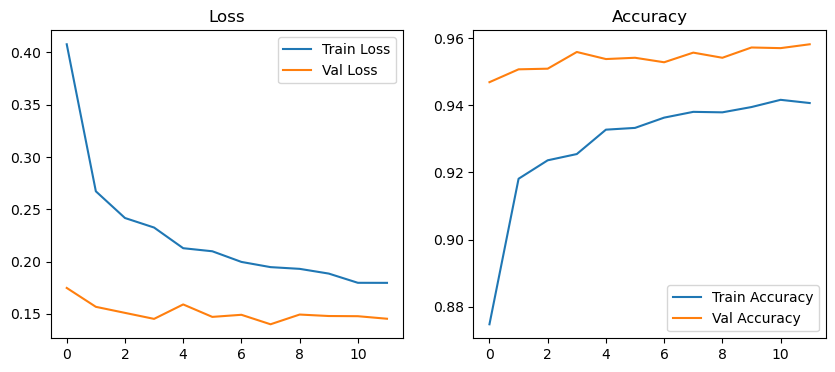

In [ ]:

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy")

plt.show()


### 6. Evaluation Metrics

In [ ]:

y_true = val_data.classes
y_pred = np.argmax(model.predict(val_data), axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

#cm = confusion_matrix(y_true, y_pred)

#plt.figure(figsize=(6,5))
#sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
#            xticklabels=class_names, yticklabels=class_names) # Not working on some versions of Seaborn
#plt.xlabel("Predicted")
#plt.ylabel("True")
#plt.title("Confusion Matrix")
#plt.show()


164/164 [==============================] - 7s 40ms/step
              precision    recall  f1-score   support

        cane       0.97      0.96      0.96       972
     cavallo       0.97      0.97      0.97       524
    elefante       0.93      0.98      0.96       289
    farfalla       0.96      0.98      0.97       422
     gallina       0.99      0.99      0.99       619
       gatto       0.95      0.94      0.94       333
       mucca       0.94      0.95      0.94       373
      pecora       0.93      0.92      0.92       364
       ragno       0.99      0.99      0.99       964
  scoiattolo       0.98      0.96      0.97       372

    accuracy                           0.97      5232
   macro avg       0.96      0.96      0.96      5232
weighted avg       0.97      0.97      0.97      5232



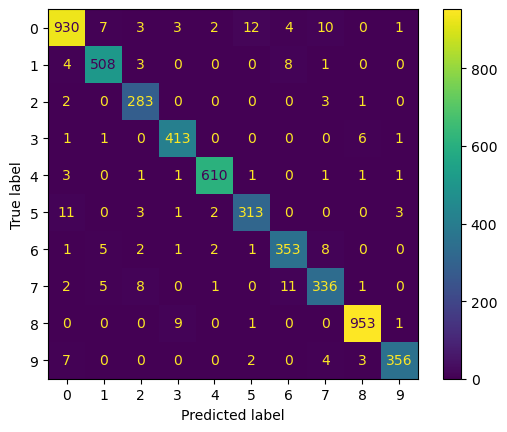

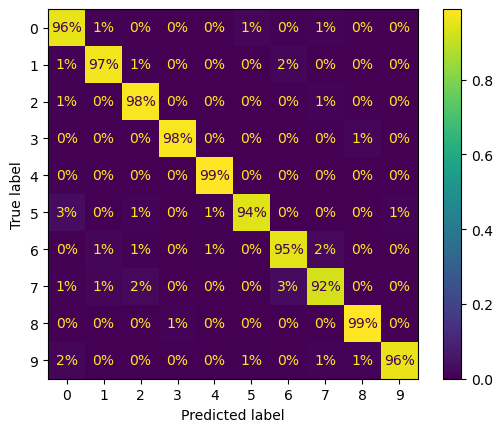

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
plt.show()

ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize="true", values_format=".0%")
plt.show()

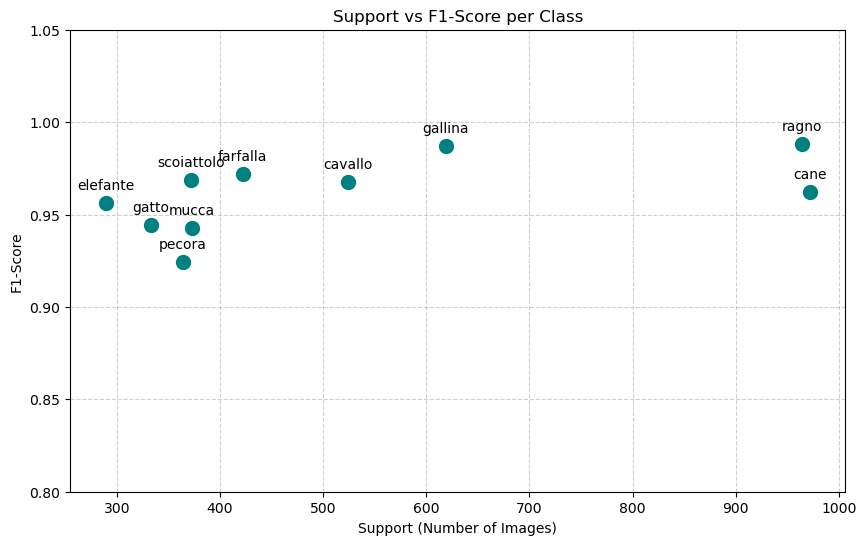

In [ ]:
import pandas as pd

# 1. Get the report as a dictionary
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

# 2. Convert to DataFrame and remove summary rows
df_report = pd.DataFrame(report).transpose()
# We only want the individual classes, not the averages at the bottom
df_classes = df_report.loc[class_names]

# plot
plt.figure(figsize=(10, 6))
plt.scatter(df_classes['support'], df_classes['f1-score'], color='teal', s=100)
for i, name in enumerate(class_names):
    plt.annotate(name, (df_classes['support'].iloc[i], df_classes['f1-score'].iloc[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center')
plt.title('Support vs F1-Score per Class')
plt.xlabel('Support (Number of Images)')
plt.ylabel('F1-Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0.8, 1.05) # F1-score is between 0 and 1
plt.show()

## 7. Questions

- Q7.a) Explain the results: precision, recall, f1-score and support?\
Looking at the macro avg, the precision is 0.94, meaning that the number of false positives are very small, the recall is 0.95 meaning that the number of false positives are very low. The f1-score is 0.95 explaining that the model is quite good to use for predictions of animals. The support is the total number of actual occurrences of each class, looking at the results there might be a corrolation between support and f1 score looking at the plot above, the f1 score is proportional to the support, this is an idication that more data is better.

- Q7.b) What is the difference between macro and weighted avg accuracy?\
Macro avg is the the sum of the accuracies divided by the number of classes, a weighted avg the sum of the products of accuracy and support of each class divided by the total support.

- Q7.c) What happens if you unfreeze the last layers of the pretrained model?
Unfreezing the pretrained model allows me to finetune the model, without this finetuning the maximum validation accuracy most likely have en stagnant around 95% but unfreezing the last layers pushed the accuracy to 96.5% by utilizing the fact that MobileNetV2 model is already trained on Imagenet dataset.
- Q7.d) Describe the different types of data augmentation that are used in the example.\
The different types of data augmentation is seen in the "train_gen" function. rescale=1./255 is a rescaling of the colors. Rotation is allowed by up to 20 degrees because of rotation_range=20. width_shift_range=0.1 and height_shift_range=0.1, shifts the image horizontally or vertically by 10%. It prevents the model from thinking the animal must always be perfectly centered in the frame. horizontal_flip=True, this randomly flips the image like a mirror.
- Q7.e) How does data augmentation influence overfitting?\
Small changes in the data are made because of data augmentation, which decreases the chance of overfitting, because the model don't just memorize the pixels from the training set, but has to recognize the features of the animal.
- Q7.f) What is the purpose of the batch normalization layers in MobileNet? \
Batch normalization scales the batch into a standart normal distribution with a mean of 0 and a variance of 1, allowing a higher leaning rate to be used without exploding the weights, which speeds up the learning. MobileNet is a lighter model. Usually, deep models are very sensitive to how the weights are initially set. If the weights are a tiny bit too high or too low, the signal disappears or grows too large. batch normalization acts as a safety net, ensuring that even if the initial weights aren't perfect, the signal remains within a good range.
- Q7.g) Change the model example to use ResNet50 and EfficientNetV2S (See https://keras.io/api/applications/)\
To use ResNet50 the 1/255 scaling is not used and for the EfficientNetV2S is scaling automatically, other than that they are very easy to implement instead of MobileNetV2.

- Q7.h) Compare MobileNetV2 with ResNet50 and EfficientNetV2S (Compare accuracy and number of training epochs in a table)\
Base on the validation accuracy from the different models and unfreezing from layer 100 an onwards for each transfer learning model and using the early stopping with a patience of 4, this was the results. Note that the highest validation accuracy is chosen for the table.

-|MobileNetV2|ResNet50|EfficientNetV2S|
:- | :- | :-| :-
Val_Acc| 0.9688| 0.9690|0.9839|                 
Epochs| 23| 18| 3|

From the table it is seen that EfficientNetV2S is both faster and more accurate than both MobileNetV2 and ResNet50.

# 16 Exercise: Time Series Forecasting with Deep Learning

This notebook introduces time series forecasting using deep learning and recurrent neural networks (RNNs) with Keras. 

You will work with a real-world weather dataset and build models that predict future temperature values.

The notebook is divided into:

- A guided demonstration using a simple RNN

- Extensions where you experiment with LSTM and GRU models

- Exercises and theory questions

**Learning Objectives**

By the end of this exercise, you should be able to:

- Prepare time series data for supervised learning

- Build and train RNN-based forecasting models in Keras

- Perform single-step and multi-step forecasting

- Compare SimpleRNN, LSTM, and GRU architectures

- Reflect on model behavior and theoretical concepts


## 1. Dataset: Weather Time Series

We use the Jena Climate Dataset, a commonly used benchmark dataset for time series forecasting.

It contains 10-minute interval measurements such as:

- Temperature

- Humidity

- Air pressure

- Wind speed

For simplicity, we start by predicting temperature only.

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


             Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1  01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2  01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
3  01.01.2009 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
4  01.01.2009 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02   
3          3.26          3.07          0.19       1.92             3.08   
4          3.27          3.08          0.19       1.92             3.09   

   rho (g/m**3)  wv (m/s)  max. wv (m/s)  wd (deg)  
0       1307.75      1.03        

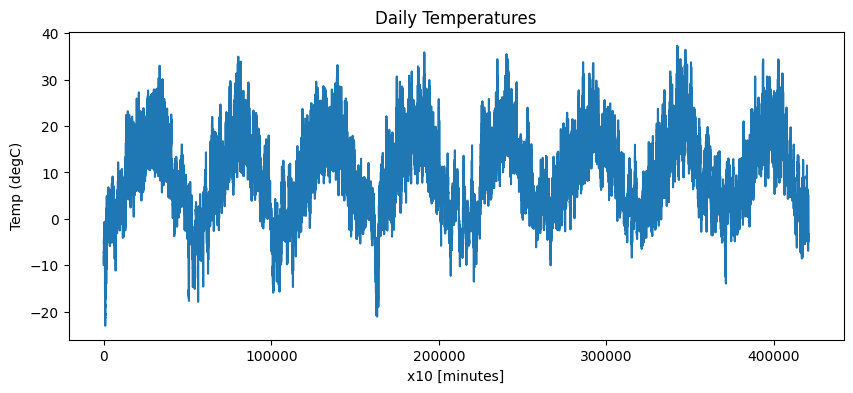

In [ ]:

# Downloaded CSV from Jena Climate dataset
url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
df = pd.read_csv(url)

print(df.head())

plt.figure(figsize=(10,4))
plt.plot(df['T (degC)'])
plt.title("Daily Temperatures")
plt.xlabel('x10 [minutes]')
plt.ylabel('Temp (degC)')
plt.show()


### Questions

- Which features are available in the dataset? \
From the information printed above we can read that we have the following features:\
The day and time \
The pressure, p, measured in millibar \
The tempearture in Celcius \
The potential Temperature in Kelvin, from what I can gather it is something like, the potiential from an adiabatic process at a fixed pressure \
The Dew Point Temeperature in Celcius \
The Relative Humidity in percent \
The saturation vapor pressure, which is the maximum pressure exerted by the water vapor at the given temperature in millibar\
The actual vapor pressure in millibar\
The vapor pressure deficit, the difference in the two above \
The specific humidity in [g/kg]\
The water vapor concentration in mmol/mol \
The air density in $g/m^3$ \
The wind velocity in $m/s$ \
The max or peak wind velocity in $m/s$ \
The wind direction in degrees\

- Which ones might be useful for forecasting temperature? \
While temperature is quite chaotic to predict, most of these features could prove usefull, the pressure was often used in barometers back in the day, the past Temperature would of course be helpfull to help predict the future Temperatures
Furthermore the humidity, to my knowledge, does not directly affect the temperature, it could however impact the rate of change since water takes more energy to heat than air does. The wind velocity and direction would also help to determine if hotter air is coming our way, it might be a problem that the direction is measured in degrees since 360 and 0 is the same but could confuse the model since they are numerically far apart.

## 2. Prepare Sequences


- Select the temperature column

- Normalize values

- Create supervised learning sequences

In [ ]:
temperature = df['T (degC)'].values.reshape(-1, 1)

scaler = MinMaxScaler()
temperature_scaled = scaler.fit_transform(temperature)

def create_sequences(data, seq_len=24):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)


SEQ_LEN = 24 # last 24 time steps
X, y = create_sequences(temperature_scaled, SEQ_LEN)

split = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]


## 3. Simple RNN Forecasting Model (Single-Step)

In [ ]:

model = Sequential([
    SimpleRNN(32, activation='tanh', input_shape=(SEQ_LEN, 1)),
    Dense(1)
    ])

model.compile(optimizer='adam', loss='mse')
model.summary()

c:\Users\bruger\.conda\envs\ml_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Train and Evaluate

In [ ]:

results = []

history = model.fit(
        X_train, y_train,
        epochs=10,
        validation_data=(X_val, y_val),
        batch_size=64
        )


Epoch 1/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1.4011e-04 - val_loss: 3.7085e-05
Epoch 2/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1.9124e-05 - val_loss: 3.1377e-05
Epoch 3/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1.3436e-05 - val_loss: 1.2270e-05
Epoch 4/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1.3016e-05 - val_loss: 1.2333e-05
Epoch 5/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1.2841e-05 - val_loss: 1.1732e-05
Epoch 6/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1.2712e-05 - val_loss: 1.2075e-05
Epoch 7/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1.2443e-05 - val_loss: 1.2021e-05
Epoch 8/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1.2447e-05 - val_loss: 1.6587e-05
Epoch 9/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1.2384e-05 - val_loss: 1.7022e-05
Epoch 10/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1.2401e-05 - val_loss: 1.1834e-05


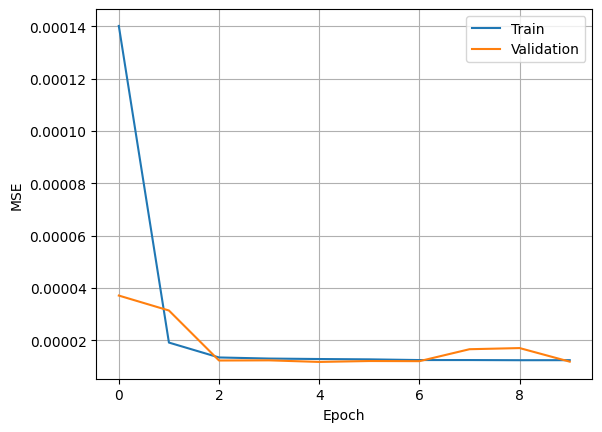

In [ ]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid()
plt.show()

## 4. Evaluate model and validation dataset

In [ ]:
preds = model.predict(X_val)

y_true = scaler.inverse_transform(y_val)
y_pred = scaler.inverse_transform(preds)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print("RMSE", rmse, "MAE", mae)


2629/2629 ━━━━━━━━━━━━━━━━━━━━ 2s 713us/step
RMSE 0.20740049467557767 MAE 0.1320114072293584


## 5. Single-Step Forecasting

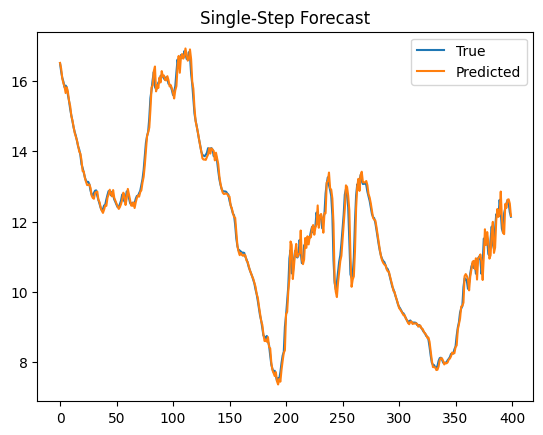

In [ ]:

plt.plot(y_true[:400], label='True')
plt.plot(y_pred[:400], label='Predicted')
plt.legend()
plt.title('Single-Step Forecast')
plt.show()


## 6. Multi-Step Forecasting

We now predict multiple future time steps recursively by using the below function.

In [ ]:
def multi_step_forecast(model, start_seq, steps=24):
    current_seq = start_seq.copy()
    preds = []
    for _ in range(steps):
        next_val = model.predict(current_seq[np.newaxis, ...])[0]
        preds.append(next_val)
        current_seq = np.roll(current_seq, -1, axis=0)
        current_seq[-1] = next_val
    return np.array(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
[[0.6555495 ]
 [0.65301275]
 [0.65046597]
 [0.64794135]
 [0.645419  ]
 [0.64288974]
 [0.6403569 ]
 [0.6378249 ]
 [0.63530946]
 [0.6328205 ]]


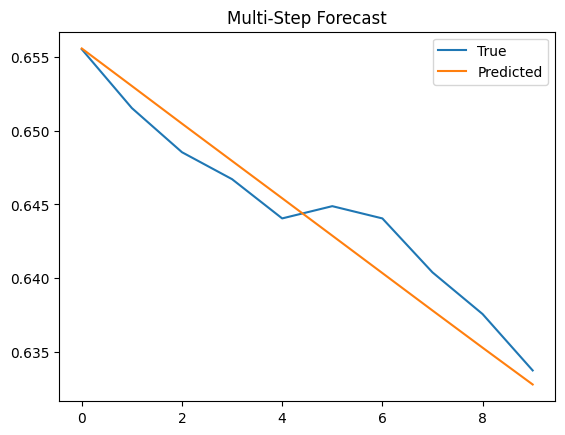

In [ ]:
preds = multi_step_forecast(model, X_val[0], steps=10)
print(preds)

plt.plot(y_val[:10], label='True')
plt.plot(preds, label='Predicted')
plt.legend()
plt.title('Multi-Step Forecast')
plt.show()

## 7. Extend model with LSTM and GRU (Task)

Replace the SimpleRNN layer with:

- LSTM

- GRU

Example:

- LSTM(32, input_shape=(SEQ_LEN, 1))

- GRU(32, input_shape=(SEQ_LEN, 1))

Compare:

- Convergence speed

- Validation loss

- Forecast stability

## LSTM

In [ ]:
model = Sequential([
    LSTM(32, input_shape=(SEQ_LEN, 1)),
    Dense(1)
    ])

model.compile(optimizer='adam', loss='mse')
model.summary()

c:\Users\bruger\.conda\envs\ml_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 4.4685e-04 - val_loss: 3.9382e-05
Epoch 2/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 3.1010e-05 - val_loss: 2.5941e-05
Epoch 3/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.7783e-05 - val_loss: 1.4978e-05
Epoch 4/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.3109e-05 - val_loss: 1.4739e-05
Epoch 5/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.2704e-05 - val_loss: 1.1733e-05
Epoch 6/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 1.2500e-05 - val_loss: 1.3569e-05
Epoch 7/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.2458e-05 - val_loss: 1.2102e-05
Epoch 8/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.2334e-05 - val_loss: 1.1754e-05
Epoch 9/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.2314e-05 - val_loss: 1.2927e-05
Epoch 10/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.2327e-05 - val_loss: 1.4371e-05


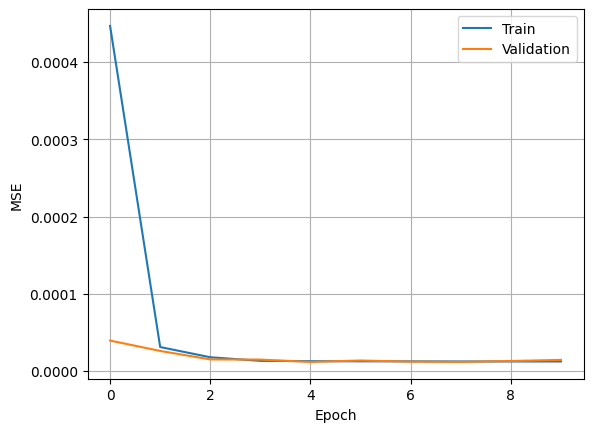

In [ ]:
results = []

history = model.fit(
        X_train, y_train,
        epochs=10,
        validation_data=(X_val, y_val),
        batch_size=64
        )

plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
[[0.6542927 ]
 [0.6498584 ]
 [0.64528346]
 [0.64057773]
 [0.63574314]
 [0.6307849 ]
 [0.6257097 ]
 [0.62052524]
 [0.6152409 ]
 [0.6098651 ]]


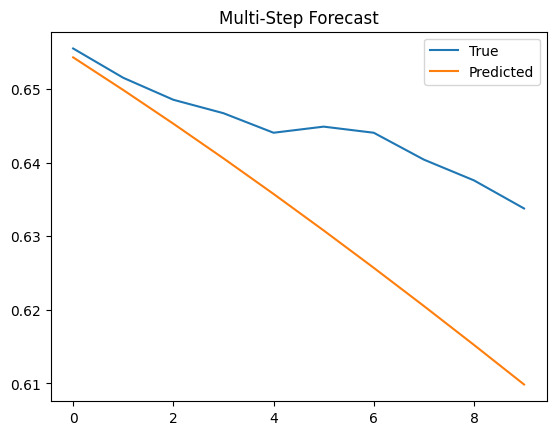

In [ ]:
preds = multi_step_forecast(model, X_val[0], steps=10)
print(preds)

plt.plot(y_val[:10], label='True')
plt.plot(preds, label='Predicted')
plt.legend()
plt.title('Multi-Step Forecast')
plt.show()

## GRU

In [ ]:
model = Sequential([
    GRU(32, input_shape=(SEQ_LEN, 1)),
    Dense(1)
    ])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 2.6323e-04 - val_loss: 1.6889e-05
Epoch 2/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 1.7321e-05 - val_loss: 2.2602e-05
Epoch 3/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 1.4099e-05 - val_loss: 1.2920e-05
Epoch 4/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 1.3183e-05 - val_loss: 2.4792e-05
Epoch 5/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 1.3016e-05 - val_loss: 1.2234e-05
Epoch 6/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - loss: 1.2808e-05 - val_loss: 1.3208e-05
Epoch 7/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - loss: 1.2657e-05 - val_loss: 1.5871e-05
Epoch 8/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 1.2674e-05 - val_loss: 1.3863e-05
Epoch 9/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 1.2595e-05 - val_loss: 1.3976e-05
Epoch 10/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 1.2458e-05 - val_loss: 1.3002e-05


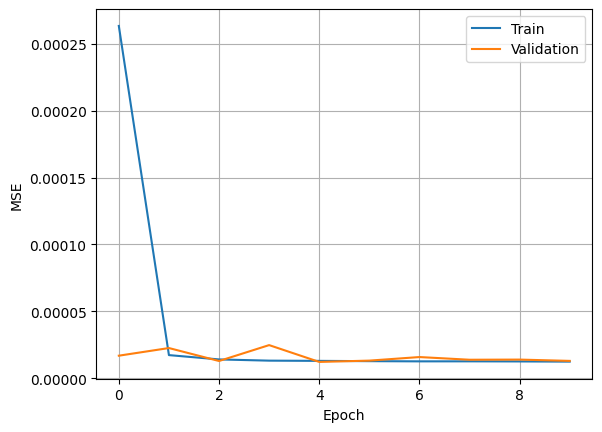

In [ ]:
results = []

history = model.fit(
        X_train, y_train,
        epochs=10,
        validation_data=(X_val, y_val),
        batch_size=64
        )

plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
[[0.6575279 ]
 [0.657856  ]
 [0.6583419 ]
 [0.6589794 ]
 [0.6598293 ]
 [0.66090167]
 [0.6621916 ]
 [0.663693  ]
 [0.6654013 ]
 [0.66731435]]


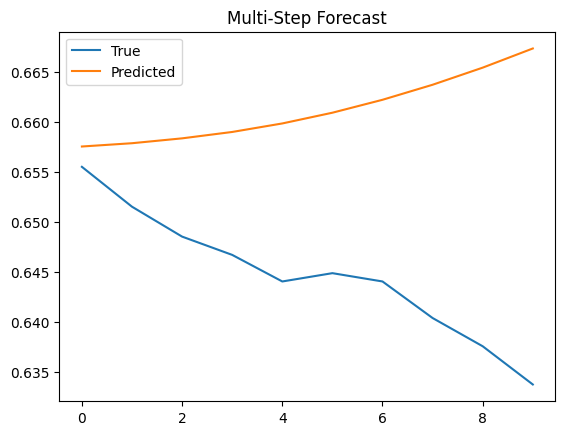

In [ ]:
preds = multi_step_forecast(model, X_val[0], steps=10)
print(preds)

plt.plot(y_val[:10], label='True')
plt.plot(preds, label='Predicted')
plt.legend()
plt.title('Multi-Step Forecast')
plt.show()

We see that for both of them the validation loss starts low and remains low in the order $10^-5$, on top of that they both seem to converge after one epoch, the thing that really sets them apart is their forecast stability, where the LSTM at least seems to get the idea and direction, albeit not as closely as the RNN model. The GRU model however, completely misses the mark and goes off in the wrong direction.

## 8. Questions and reflection

### Questions

- Q8.a) Why are RNNs suitable for time series forecasting? \
RNNs do better due to their "feedback loop" where they not only consider the input at say time t, but also the previous state e.g. t-1. It is part of the fundamentals of the RNN that maintains a hidden state, which functions as a form of memory. This makes it better at not only learning and predicting one value from the given features, but predict the direction of the coming values based on those that came before. (Source: wikipedia "Recurrent Neural Network") \

- Q8.b) What are the limitations of RNN-based forecasting? \
RNNs do however suffer from a vanishing gradient problem, where the gradients used to update the weights shrink exponentially when looking furhter back in time, which lead to what can be described as a long term memory lapse, where the short term memory gains bigger influence than the long term. 

- Q8.c) What problem does LSTM solve compared to SimpleRNN? \
The LSTM or Long Short-Term Memory network tries to solve this by adding gates that keeps track of the older gradients for longer expanding the memory of the model.\

- Q8.d) What causes error accumulation in multi-step forecasting? \
Oftentimes the problem is the fact that when predicting say 3 days ahead, the model will predict one day ahead and use that prediction as the input for the prediction for day two, that way the errors will compound and grow the further down the future we move. \

- Q8.e) How does sequence length affect forecasting performance? \
Too short of a sequence length will lead to too little knowledge to properly predict, if we say only had the weather for the night it would be hard to predict the warmth of the sun during the day. If the sequence length becomes too long we either hit the problem of the vanishing gradient with the RNN or we force the LSTM to carry so much data that the .fit will take far too much time, probably with data that does not make that big a difference. Like life it is about finding the balance.

- Q8.f) Which model performed best and why? \
All three models hit about the same validation loss, but the prediction power of the RNN became clear when performing the multi step forecast. To be more specific the RNN also reached the best validation loss of the three. It might be because the LSTM ends up overfitting and considering the data too long back, which when working with the weather might skew the predictions, as the seasons change.



# L20 - Gridsearch
What should the default value in the sk-learn.svm.SVC class be set to other than 'rbf'?

```python
class sklearn.svm.SVC(
    C=1.0, 
    kernel=’rbf’, 
    degree=3,
    gamma=’auto_deprecated’, 
    coef0=0.0, 
    shrinking=True, 
    probability=False, 
    tol=0.001, 
    cache_size=200, 
    class_weight=None, 
    verbose=False, 
    max_iter=-1, 
    decision_function_shape=’ovr’, 
    random_state=None
  )
```  

A first alternative would be 'linear' such that the class boundary becomes a line. Another alternative is 'poly' for a polynomium.

### Qa Explain GridSearchCV
Review the code in the code cells 1) function setup, 2) the actual grid-search and write a short summary, mainly fouced on cell 2. Focus especially on the lines:
```python
grid_tuned = GridSearchCV(model, tuning_parameters, ..
grid_tuned.fit(X_train, y_train)
..
FullReport(grid_tuned , X_test, y_test, time_gridsearch)
```
And explain how `GridSearchCV` works, how the search parameters set is created along with how the overall search mechanism functions. Finally, what role does the parameter `scoring='f1_micro'` play in the `GridSearchCV` and what does `n_jobs=-1` mean?


Code cell 1) the function setup, start by importing all the necessary packages and modeles. It then sets up a global variable defining the model along with a function to print information about the best model found during a given search, 'SearchReport'. This function furthermore uses a helper function, GetBestModelCtor with the nested function GetParams to create a string describing the model. The function thus returns both a short summary string and the best fitted model. The next function 'ClassificationReport' tests evaluates a given model on a test set. 'FullReport' combines the previous function thereby giving a full report of the best model. 'LoadAndSetupData' loads the dataset and splits it into training and testset, the allowed modes/datasets are in this case iris, minst and moon while the default test size is 0.3. It also updates the global variable to the mode. Finally, the last function 'TryKerasImport' checks whether keras is installed using a boolean statement. Code cell 1) is thus mainly for setting up helper functions.

Code cell 2) the actual grid-search, then uses the helper functions from code cell 1) to train several SVM models using gridsearch, evaluating the best one and print the report. It starts by loading and splitting the data using the 'LoadAndSetupData' function, it then creates a base Support vector classifier model (SVM) and defining the hyperparameters the gridsearch has to use, with 2 kernels and 3 C-values for a total of 6 combinations. It also sets CV=5, which means it uses 5 cross-validations, while VERBOSE=0, prevents it from printing during the gridsearch. The line "grid_tuned = GridSearchCV(model, tuning_parameters, .." then creates the GridsearchCV object with the arguments. It then trains and times the gridsearch. The line "grid_tuned.fit(X_train, y_train)" is the one that actually runs the gridseacrh on the data and "FullReport(grid_tuned , X_test, y_test, time_gridsearch)" then prints the full report of the best model.

`GridSearchCV` is thus a tool that automatically tries different hyperparameter combinations and selects the best one using cross-validation. It works using a base model as an input along with vectors of hyperparameters we want the gridsearch to try, where it then sets up each of the models to best tested. To test them it uses cross-validation. The actual search begines when .fit() is called which begines the testing of the different models.

`scoring='f1_micro'` defines the score the models are judged based on, which in this case is the micr-averaged f1 score of the cross-validation results. Finally, `n_jobs=-1`, tells `GridSearchCV` to use all availabe CPU cores when performing the search, which allows it to try to run several models in parrallel. If this number was 1,2,3 or 4 instead the search would instead use that number of CPU cores.


In [ ]:
# TODO: Qa, code review..cell 1) function setup

from time import time
import numpy as np
import sys
sys.path.append("/home/swmal19f26/GITMAL")
from sklearn import svm
from sklearn.linear_model import SGDClassifier

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn import datasets
from libitmal import dataloaders as itmaldataloaders # Needed for load of iris, moon and mnist

currmode="N/A" # GLOBAL var!

def SearchReport(model): 
    
    def GetBestModelCTOR(model, best_params):
        def GetParams(best_params):
            ret_str=""          
            for key in sorted(best_params):
                value = best_params[key]
                temp_str = "'" if str(type(value))=="<class 'str'>" else ""
                if len(ret_str)>0:
                    ret_str += ','
                ret_str += f'{key}={temp_str}{value}{temp_str}'  
            return ret_str          
        try:
            param_str = GetParams(best_params)
            return type(model).__name__ + '(' + param_str + ')' 
        except:
            return "N/A(1)"
        
    print("\nBest model set found on train set:")
    print()
    print(f"\tbest parameters={model.best_params_}")
    print(f"\tbest '{model.scoring}' score={model.best_score_}")
    print(f"\tbest index={model.best_index_}")
    print()
    print(f"Best estimator CTOR:")
    print(f"\t{model.best_estimator_}")
    print()
    try:
        print(f"Grid scores ('{model.scoring}') on development set:")
        means = model.cv_results_['mean_test_score']
        stds  = model.cv_results_['std_test_score']
        i=0
        for mean, std, params in zip(means, stds, model.cv_results_['params']):
            print("\t[%2d]: %0.3f (+/-%0.03f) for %r" % (i, mean, std * 2, params))
            i += 1
    except:
        print("WARNING: the random search do not provide means/stds")
    
    global currmode                
    assert "f1_micro"==str(model.scoring), f"come on, we need to fix the scoring to be able to compare model-fits! Your scoreing={str(model.scoring)}...remember to add scoring='f1_micro' to the search"   
    return f"best: dat={currmode}, score={model.best_score_:0.5f}, model={GetBestModelCTOR(model.estimator,model.best_params_)}", model.best_estimator_ 

def ClassificationReport(model, X_test, y_test, target_names=None):
    assert X_test.shape[0]==y_test.shape[0]
    print("\nDetailed classification report:")
    print("\tThe model is trained on the full development set.")
    print("\tThe scores are computed on the full evaluation set.")
    print()
    y_true, y_pred = y_test, model.predict(X_test)                 
    print(classification_report(y_true, y_pred, target_names=target_names))
    print()
    
def FullReport(model, X_test, y_test, t):
    print(f"SEARCH TIME: {t:0.2f} sec")
    beststr, bestmodel = SearchReport(model)
    ClassificationReport(model, X_test, y_test)    
    print(f"CTOR for best model: {bestmodel}\n")
    print(f"{beststr}\n")
    return beststr, bestmodel
    
def LoadAndSetupData(mode, test_size=0.3):
    assert test_size>=0.0 and test_size<=1.0
    
    def ShapeToString(Z):
        n = Z.ndim
        s = "("
        for i in range(n):
            s += f"{Z.shape[i]:5d}"
            if i+1!=n:
                s += ";"
        return s+")"

    global currmode
    currmode=mode
    print(f"DATA: {currmode}..")
    
    if mode=='moon':
        X, y = itmaldataloaders.MOON_GetDataSet(n_samples=5000, noise=0.2)
        itmaldataloaders.MOON_Plot(X, y)
    elif mode=='mnist':
        X, y = itmaldataloaders.MNIST_GetDataSet(load_mode=0)
        if X.ndim==3:
            X=np.reshape(X, (X.shape[0], -1))
    elif mode=='iris':
        X, y = itmaldataloaders.IRIS_GetDataSet()
    else:
        raise ValueError(f"could not load data for that particular mode='{mode}', only 'moon'/'mnist'/'iris' supported")
        
    print(f'  org. data:  X.shape      ={ShapeToString(X)}, y.shape      ={ShapeToString(y)}')

    assert X.ndim==2
    assert X.shape[0]==y.shape[0]
    assert y.ndim==1 or (y.ndim==2 and y.shape[1]==0)    
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=0, shuffle=True
    )
    
    print(f'  train data: X_train.shape={ShapeToString(X_train)}, y_train.shape={ShapeToString(y_train)}')
    print(f'  test data:  X_test.shape ={ShapeToString(X_test)}, y_test.shape ={ShapeToString(y_test)}')
    print()
    
    return X_train, X_test, y_train, y_test

def TryKerasImport(verbose=True):
    
    kerasok = True
    try:
        import keras as keras_try
    except:
        kerasok = False

    tensorflowkerasok = True
    try:
        import tensorflow.keras as tensorflowkeras_try
    except:
        tensorflowkerasok = False
        
    ok = kerasok or tensorflowkerasok
    
    if not ok and verbose:
        if not kerasok:
            print("WARNING: importing 'keras' failed", file=sys.stderr)
        if not tensorflowkerasok:
            print("WARNING: importing 'tensorflow.keras' failed", file=sys.stderr)

    return ok
    
print(f"OK(function setup" + ("" if TryKerasImport() else ", hope MNIST loads works because it seems you miss the installation of Keras or Tensorflow!") + ")")

OK(function setup)


In [ ]:
# TODO: Qa, code review..cell 2) the actual grid-search

# Setup data
X_train, X_test, y_train, y_test = LoadAndSetupData(
    'iris')  # 'iris', 'moon', or 'mnist'

# Setup search parameters
model = svm.SVC(
    gamma=0.001
)  # NOTE: gamma="scale" does not work in older Scikit-learn frameworks,
# FIX:  replace with model = svm.SVC(gamma=0.001)

tuning_parameters = {
    'kernel': ('linear', 'rbf'), 
    'C': [0.1, 1, 10]
}

CV = 5
VERBOSE = 0

# Run GridSearchCV for the model
grid_tuned = GridSearchCV(model,
                          tuning_parameters,
                          cv=CV,
                          scoring='f1_micro',
                          verbose=VERBOSE,
                          n_jobs=-1)

start = time()
grid_tuned.fit(X_train, y_train)
t = time() - start

# Report result
b0, m0 = FullReport(grid_tuned, X_test, y_test, t)
print('OK(grid-search)')

DATA: iris..
  org. data:  X.shape      =(  150;    4), y.shape      =(  150)
  train data: X_train.shape=(  105;    4), y_train.shape=(  105)
  test data:  X_test.shape =(   45;    4), y_test.shape =(   45)

SEARCH TIME: 4.55 sec

Best model set found on train set:

	best parameters={'C': 1, 'kernel': 'linear'}
	best 'f1_micro' score=0.9714285714285715
	best index=2

Best estimator CTOR:
	SVC(C=1, gamma=0.001, kernel='linear')

Grid scores ('f1_micro') on development set:
	[ 0]: 0.962 (+/-0.093) for {'C': 0.1, 'kernel': 'linear'}
	[ 1]: 0.371 (+/-0.038) for {'C': 0.1, 'kernel': 'rbf'}
	[ 2]: 0.971 (+/-0.047) for {'C': 1, 'kernel': 'linear'}
	[ 3]: 0.695 (+/-0.047) for {'C': 1, 'kernel': 'rbf'}
	[ 4]: 0.952 (+/-0.085) for {'C': 10, 'kernel': 'linear'}
	[ 5]: 0.924 (+/-0.097) for {'C': 10, 'kernel': 'rbf'}

Detailed classification report:
	The model is trained on the full development set.
	The scores are computed on the full evaluation set.

              precision    recall  f1-score  

### Qb Hyperparameter Grid Search using an SDG classifier
Replace the `svm.SVC` model with an `SGDClassifier` and a suitable set of the hyperparameters for that model instead.

The code for the `SGDClassifier` is basically the same as code cell 2) above, except the model is changed and different hyperparameters are used for the corresponding model. For the `SGDClassifier` we choose to use the hyperparameters, loss, penalty and alpha. See code cell below implementation. 

Loss controls the type of classifier, in this case either hinge for a linear or log_loss for logistic regression. Penalty controls the regularization, where the common, l1, l2 and elasticnet is used and alpha controls the size of the regularization. 

In [ ]:
#Qb - SDG classifier
# Setup data
X_train, X_test, y_train, y_test = LoadAndSetupData(
    'iris')  # 'iris', 'moon', or 'mnist'

# Setup search parameters
model = SGDClassifier(
    random_state=0, max_iter=500, tol=1e-5
) 

tuning_parameters = {
    'loss': ['hinge', 'log_loss'], 
    'penalty': ['l1', 'l2', 'elasticnet'],
    'alpha': [0.0001, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.2]
}

CV = 5
VERBOSE = 0

# Run GridSearchCV for the model
grid_tuned = GridSearchCV(model,
                          tuning_parameters,
                          cv=CV,
                          scoring='f1_micro',
                          verbose=VERBOSE,
                          n_jobs=-1)

start = time()
grid_tuned.fit(X_train, y_train)
t = time() - start

# Report result
b0, m0 = FullReport(grid_tuned, X_test, y_test, t)

DATA: iris..
  org. data:  X.shape      =(  150;    4), y.shape      =(  150)
  train data: X_train.shape=(  105;    4), y_train.shape=(  105)
  test data:  X_test.shape =(   45;    4), y_test.shape =(   45)

SEARCH TIME: 0.21 sec

Best model set found on train set:

	best parameters={'alpha': 0.006, 'loss': 'hinge', 'penalty': 'l1'}
	best 'f1_micro' score=0.9904761904761905
	best index=36

Best estimator CTOR:
	SGDClassifier(alpha=0.006, max_iter=500, penalty='l1', random_state=0,
              tol=1e-05)

Grid scores ('f1_micro') on development set:
	[ 0]: 0.876 (+/-0.311) for {'alpha': 0.0001, 'loss': 'hinge', 'penalty': 'l1'}
	[ 1]: 0.790 (+/-0.230) for {'alpha': 0.0001, 'loss': 'hinge', 'penalty': 'l2'}
	[ 2]: 0.790 (+/-0.196) for {'alpha': 0.0001, 'loss': 'hinge', 'penalty': 'elasticnet'}
	[ 3]: 0.781 (+/-0.222) for {'alpha': 0.0001, 'loss': 'log_loss', 'penalty': 'l1'}
	[ 4]: 0.695 (+/-0.196) for {'alpha': 0.0001, 'loss': 'log_loss', 'penalty': 'l2'}
	[ 5]: 0.781 (+/-0.293) for 

### Qc Hyperparameter Random  Search using an SDG classifier

Change the code to run a `RandomizedSearchCV` instead. Use these default parameters for the random search.

```python
random_tuned = RandomizedSearchCV(
    model, 
    tuning_parameters, 
    n_iter=20, 
    random_state=42, 
    cv=CV, 
    scoring='f1_micro', 
    verbose=VERBOSE, 
    n_jobs=-1
)
```

Where the two new parameters, `n_iter` and `random_state` are added. Explain the `n_iter` parameter both in code and conceputally. Is the random search best model close to the grid search model?

To change the code to a randomized search instead, the grid_tuned object is changed to the given random_tuned object and random_tuned.fit is then used instead of grid_tuned.fit. See implementation in code cell below.

Regarding the `n_iter` parameter, it determines how many random combinations is attempted. The randomized search works by randomly combining the given parameter and `n_iter` then determines how many combinations is attempted before the best among them is evaluted. In implementation it is here important to consider that if `n_iter` is larger than the number of possible combination, the results will the be the same as for grid_search.

This expected outcome also results from the setup models, with both the parameters and results being exactly the same for large `n_iter`. If the number of possible combinations is increased, by for example massively increasing the amount of alpha parameters, this changes. The alpha value of the randomized search is still rather to close to the gridsearch but both the loss and penalty hyper parameter has changed.

In [ ]:
#Qc - Random search
# Setup data
X_train, X_test, y_train, y_test = LoadAndSetupData(
    'iris')  # 'iris', 'moon', or 'mnist'

# Setup search parameters
model = SGDClassifier(
    random_state=0, max_iter=500, tol=1e-5
) 

tuning_parameters = {
    'loss': ['hinge', 'log_loss'], 
    'penalty': ['l1', 'l2', 'elasticnet'],
    'alpha': [0.0001, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.2]
}

CV = 5
VERBOSE = 0

# Run RandomizedSearchCV for the model
random_tuned = RandomizedSearchCV(
    model, 
    tuning_parameters, 
    n_iter=10, 
    random_state=42, 
    cv=CV, 
    scoring='f1_micro', 
    verbose=VERBOSE, 
    n_jobs=-1
)

start = time()
random_tuned.fit(X_train, y_train)
t = time() - start

# Report result
b0, m0 = FullReport(random_tuned, X_test, y_test, t)

DATA: iris..
  org. data:  X.shape      =(  150;    4), y.shape      =(  150)
  train data: X_train.shape=(  105;    4), y_train.shape=(  105)
  test data:  X_test.shape =(   45;    4), y_test.shape =(   45)

SEARCH TIME: 0.04 sec

Best model set found on train set:

	best parameters={'penalty': 'elasticnet', 'loss': 'log_loss', 'alpha': 0.03}
	best 'f1_micro' score=0.9333333333333332
	best index=5

Best estimator CTOR:
	SGDClassifier(alpha=0.03, loss='log_loss', max_iter=500, penalty='elasticnet',
              random_state=0, tol=1e-05)

Grid scores ('f1_micro') on development set:
	[ 0]: 0.895 (+/-0.071) for {'penalty': 'l2', 'loss': 'hinge', 'alpha': 0.03}
	[ 1]: 0.819 (+/-0.265) for {'penalty': 'l2', 'loss': 'hinge', 'alpha': 0.003}
	[ 2]: 0.819 (+/-0.185) for {'penalty': 'elasticnet', 'loss': 'hinge', 'alpha': 0.1}
	[ 3]: 0.914 (+/-0.164) for {'penalty': 'l2', 'loss': 'hinge', 'alpha': 0.02}
	[ 4]: 0.819 (+/-0.203) for {'penalty': 'l2', 'loss': 'log_loss', 'alpha': 0.06}
	[ 5]: 0

### Qd MNIST Search Quest II

Report the progress in scoring choosing different models, hyperparameters to search for the search-quest competition using the MNIST data. Also note how you might need to the preprocess your data.

We start by trying SGDClassifier with the hyperparameters 'loss', 'penalty' and 'alpha' from the previous exercises on the new dataset. This gives the result:

best: dat=mnist, score=0.88382, model=SGDClassifier(alpha=0.06,loss='log_loss',penalty='l2')

Which is quite a low score compared to what we are typically looking for. To increase the score, we first try to preprocess the data a bit, as suggested, by adding a standard scaler. The SGDclassifier is quite sensitive to the scale of the input features, since it is gradient based and some features might therefore dominate if not properly scaled. The standard model is added to the model part of the setup of search parameters as:
```python
model = Pipeline([
    ('scaler', StandardScaler()),
    ('sgd', SGDClassifier(...))
])
```
This was signficantly faster and resulted in:

best: dat=mnist, score=0.90284, model=Pipeline(sgd__alpha=0.003,sgd__loss='hinge',sgd__penalty'=l2)

Which is a better score but we should be able to do even better. We try to add a few more hyperparameters to see whether they have a significant effect. The added hyperparameter are the learnings rates "optimal" and "adaptive" along with the initial learning rate, eta0. This then gives

best: dat=mnist, score=0.91814, model=Pipeline(sgd__alpha=0.003,sgd__eta0=0.01,sgd__learning_rate='adaptive',sgd__loss='hinge',sgd__penalty='elasticnet)

Which is again slightly better. We then try to change the model to a Random Forest Classifier. The chosen hyperparameters to consider for this classifier is the number of tress, 'n_estimators', how complex the trees are allowed to get, 'max_depth', the minimum number of samples for a tree node to split, 'min_sample_split' and finally, how many features each tree is allowed to consider when looking for the best split, 'max features This then results in the following score:

best: dat=mnist, score=0.96716, model=RandomForestClassifier(max_depth=None,max_features='sqrt',min_samples_split=5,n_estimators=30)

Which is a quite good improvement compared to the previous models. This model is also significantly faster than the SGDClassifiers. As a final attempt at an even better score, we try a SVC model with the hyperparameters, 'C', controlling regularization, 'kernel', controlling the decision boundary and 'gamma' controlling how flexible the boundary is. The pipeline is also readded since SVC is sensative to feature scaling. This gives

best: dat=mnist, score=0.93053, model=Pipeline(svc__C=0.1,svc__gamma=0.001,svc__kernel='linear')

Because SVC is a CPU-based method, the computation took a really long time and we had to remove some of the more complicated models, including the rbf and poly kernels, simply because they took way too long to run. Because of this, the above score only represents the linear SVC models but it is still quite a good score, only surpassed by the Random Forest Classfier.

The best score, however, is then the one from the Random Forest Classifier which is the one that will be submitted to search quest competetion.



In [ ]:
# Qd - mnist search quest
# Setup data
X_train, X_test, y_train, y_test = LoadAndSetupData(
    'mnist')  # 'iris', 'moon', or 'mnist'

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
# Setup search parameters
model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

tuning_parameters = {
    'svc__kernel': ['linear'], 
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': [0.001, 0.01, 0.1]
}

CV = 5
VERBOSE = 0

# Run RandomizedSearchCV for the model
random_tuned = RandomizedSearchCV(
    model, 
    tuning_parameters, 
    n_iter=3, 
    random_state=42, 
    cv=CV, 
    scoring='f1_micro', 
    verbose=VERBOSE, 
    n_jobs=-1
)

start = time()
random_tuned.fit(X_train, y_train)
t = time() - start

# Report result
b0, m0 = FullReport(random_tuned, X_test, y_test, t)

DATA: mnist..
  org. data:  X.shape      =(70000;  784), y.shape      =(70000)
  train data: X_train.shape=(49000;  784), y_train.shape=(49000)
  test data:  X_test.shape =(21000;  784), y_test.shape =(21000)

SEARCH TIME: 2260.32 sec

Best model set found on train set:

	best parameters={'svc__kernel': 'linear', 'svc__gamma': 0.001, 'svc__C': 0.1}
	best 'f1_micro' score=0.9305306122448981
	best index=2

Best estimator CTOR:
	Pipeline(steps=[('scaler', StandardScaler()),
                ('svc', SVC(C=0.1, gamma=0.001, kernel='linear'))])

Grid scores ('f1_micro') on development set:
	[ 0]: 0.914 (+/-0.005) for {'svc__kernel': 'linear', 'svc__gamma': 0.01, 'svc__C': 100}
	[ 1]: 0.914 (+/-0.005) for {'svc__kernel': 'linear', 'svc__gamma': 0.001, 'svc__C': 100}
	[ 2]: 0.931 (+/-0.006) for {'svc__kernel': 'linear', 'svc__gamma': 0.001, 'svc__C': 0.1}

Detailed classification report:
	The model is trained on the full development set.
	The scores are computed on the full evaluation set.

   

\section{L21 Supergruppe diskussion}
\subsection{Look at the big picture and then frame the problem} \
The first task in machine learning is the understand and frame the problem. Before beginning to work on the project it is important to first understand what the goal is, since building the model itself is rarely the real goal. This is important for how algorithms and performance measures are selected later. 
Here it is important to frame whether the problem is supervised, unsupervised or reinforcement learning and whether it is a classification task, a regression task, or something else along with what techniques to use. 
Selecting the performance measure is also important. A typical performance measure for a regression problem is for example the Root Mean Square Error (RMSE), which giver a higher weight for larger errors. Another is the Mean Absolute Error (MAE) which helps with outliers. 
A last important step is to check the assumptions to make sure that what we are trying to do is what we want. 

The example of the chapter is California Housing Prices, with features such as sq.ft, median income, etc. Predictions are made on a district basis.
Framing the problem is then asking the question is it speed, accuracy, precision or other scores that will have most impact on the goal of the model?
Should we use, supervised, unsupervised, Reinforcement learning? Is it necessary to perform online learning here? no because there is no reason to expect rapid masses of incoming new data.
\newline CHECK THE ASSUMPTIONS, how good does the results really need to be? or is a range all that it takes?
\subsection{Test/Train the big split}
To ensure that we have unseen data to test the score of the model chosen the data set should be split before we ever train our model on it. To ensure that the model does not see all the data given several runthroughs one can either choose a "random" state, which ensures that even though the data selected for testing is random, it is the same random sample each time. other methods include simply choosing the rows/columns to be set aside, this should consider the chance that the dataset might be sorted before we get it and so one should not headlessly test on the last 20 percent of rows as they might be the highest values.
\subsection{Discover and visualize the data}
More than simply doing a histogram of the data it might be beneficial to create some scatter plots of the data to look for outliers as well as study the general patterns. One can use "alpha=0.1" to highlight dense areas of data.
In the housing examples these plots help realize that it could be good to employ a clustering algorithm to detect the main clusters in the data.
To find correlations one can call the ".corr()" command which ranges the correspondance between a feature and the y value (so if one feature increases, how much effect will it have on the house price?) this ranges from -1;1. One can also use the pandas scatter-matrix which plots attributes against each other, carefull it will plot all attributes against all the others so $n_{attributes}^2$ which will not help understanding much.
\subsection{Prepare the data for MLA}
Should NOT be hardcoded. In the case of the housing prices, the attribute total bedrooms is not "full rank" there are some values missing, this should be looked at since empty inputs might screw up the model. We can either choose to not look at all at those districts, we can look at our correnspondance values from earlier and determine that we can live without the total bedrooms attribute entirely or we can place the median total bedroom value in the NaN boxes to allow the model to run on everything with, hopefully, little disturbance from fake data.
We can use sklearn's "SimpleImputer" for the last option. simply with (strategy="median"). Ensure that all data fed to this call is numerical i.e. remove strings if there are any. This is the most stable method as it prepares us for when there might be other data missing from new sets later on. Solving the text/string problem is more of an intuition choice, for something like (bad, medium, good) the strings could easily be change into values ranging from say 1 to 3, but in our case where the possibilities are less scalable, we might need to focus only on the heaviest significanse like "either it is <1h from the ocean or not" and then binary encode this. Some data is lost but at least the attribute is somewhat still considered.
Feature scaling is another important step to consider. Most models don't like when the features are numerically very different, in particular neural networks mainly work with data between -1 and 1. It is often easily fixed by use of a minmaxScaler. Note: minmax is a bit vulnerable to outliers, in that case it might be better to use StandardScaler which ensure the distribution has unit variance.
\subsection{Select and train a model}
It is time to select which model to use, in the book they first choose a linear regressor but this has a RMSE about the size of the dataset so clearly it is not very good. We then look to a DecisionTreeRegressor, which is a nonlinear model, this however seems to badly overfit to the data giving a RMSE=0.0 which is never a good sign. Also because the book initially tests on the train data, which shows clear overfitting. 
Instead of intermittenly testing on our train data we can employ the K-fold-crossvalidation which picks out a tenth of the train data to test on for just this case. This is then done 10 times so we test and train on all the train data, which allows us a representable score value without spoiling the test set yet. Now the tree model looks even worse than the linear model, we have not found the solution yet.
Lastly we try the RandomForest model which looks to be the best but still not very good, further steps include trying a few more models and maybe tuning some parameters on the most promising models.
\subsection{Fine-tune the model}
Instead of slightly changing a lot of hyperparameters sklearn has a function "GridSearchCV" which we simply tell which hyper parameters to fiddle with and then it will look in ranges we choose. Even for small ranges of values we quickly end up training the model $10^2$ times, so one should think a bit about where the area of optimum migt lie.
When run in the book the best values are returned as the max we set when calling the grid search so it might be good to run it again with these as our lower boundary.
Instead of the controlled grid search which might spend much time on nonusable values, one could instead apply a randomized search which might not hit the best ever parameter combination, but can cover a lot more ground faster than the grid search and we can choose how many iterations it should run for.
\subsubsection{Evaluate on test set}
Time to find out how well we really did. Find the test data, DO NOT FIT, but feed it into the tuned model using .predict the find the score of these predictions compared to the real $y_{test}$ bum.
The performance will usually be slightly worse than when we ran the k-fold but this is because our hyper parameters have been "overfitted" to the train data. This is not cause for action since we would then just overfit a bit more to our test data, which does not help the case for new data.
In the end the model is not better than what the company was doing but it might be faster and cheaper and could improve the flow if combined with the "experts".

\subsection{Launch, Monitor, and Maintain the System}
Keep an eye on the performance of the system using monitering code, evaluate the system's performance regularly since slight drops in data quality might not cause alerts in time, especially if it is some of the low correlation data.
We should also retrain the model using fresh data so we can catch if people suddenly want to live far from neighbors in small homes far from the ocean (WWIII).
yes

\subsection{Try It Out!}
Much of the work regarding machine learning lies in the data preparation, building monitoring tools, setting up human evaluation pipelines and automating regular model training. These steps form the basis of the machine learning process, and it is therefore often preferable to be familiar with this overall process and know a few machine learning algorithms than to jump straight into advanced algorithms.   

# L22 - N-gram Language Models


---
## 1. Setup — Install / Import Libraries


In [ ]:
import math
import random
import collections

try:
    import matplotlib.pyplot as plt

    import nltk
    from nltk.corpus import gutenberg
    from nltk.lm import MLE, Laplace, KneserNeyInterpolated
    from nltk.lm.preprocessing import padded_everygram_pipeline, pad_both_ends
    from nltk.util import ngrams
except ImportError as e:
    print(f"LIbraries not installed: {e}")
    print("Installing libraries.")
    %pip install matplotlib nltk


# Download required NLTK data (only needed once)
for resource in ['gutenberg', 'punkt', 'punkt_tab']:
    nltk.download(resource, quiet=True)

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 2. Choose a Text


In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────
TEXT_ID = 'chesterton-brown.txt'   # <-- change this to try a different text
RANDOM_SEED = 42                   # for reproducibility
# ──────────────────────────────────────────────────────────────────────────────

# Print all available Gutenberg files for reference
print('Available texts in NLTK Gutenberg corpus:')
for fid in gutenberg.fileids():
    words = gutenberg.words(fid)
    sents = gutenberg.sents(fid)
    print(f'  {fid:35s}  {len(words):>7,} words   {len(sents):>5,} sentences')

Available texts in NLTK Gutenberg corpus:
  austen-emma.txt                      192,427 words   7,752 sentences
  austen-persuasion.txt                 98,171 words   3,747 sentences
  austen-sense.txt                     141,576 words   4,999 sentences
  bible-kjv.txt                        1,010,654 words   30,103 sentences
  blake-poems.txt                        8,354 words     438 sentences
  bryant-stories.txt                    55,563 words   2,863 sentences
  burgess-busterbrown.txt               18,963 words   1,054 sentences
  carroll-alice.txt                     34,110 words   1,703 sentences
  chesterton-ball.txt                   96,996 words   4,779 sentences
  chesterton-brown.txt                  86,063 words   3,806 sentences
  chesterton-thursday.txt               69,213 words   3,742 sentences
  edgeworth-parents.txt                210,663 words   10,230 sentences
  melville-moby_dick.txt               260,819 words   10,059 sentences
  milton-paradise.txt         

---
## 3. Explore the Text


In [ ]:
raw_text = gutenberg.raw(TEXT_ID)
all_sents = list(gutenberg.sents(TEXT_ID))

print(f'Text: {TEXT_ID}')
print(f'Total characters : {len(raw_text):,}')
print(f'Total sentences  : {len(all_sents):,}')
print(f'Total words      : {len(gutenberg.words(TEXT_ID)):,}')
print()
print('── First 500 characters ──────────────────────────────────────────────────')
print(raw_text[:500])
print('...')

Text: chesterton-brown.txt
Total characters : 406,629
Total sentences  : 3,806
Total words      : 86,063

── First 500 characters ──────────────────────────────────────────────────
[The Wisdom of Father Brown by G. K. Chesterton 1914]


I. The Absence of Mr Glass


THE consulting-rooms of Dr Orion Hood, the eminent criminologist
and specialist in certain moral disorders, lay along the sea-front
at Scarborough, in a series of very large and well-lighted french windows,
which showed the North Sea like one endless outer wall of blue-green marble.
In such a place the sea had something of the monotony of a blue-green dado:
for the chambers themselves were ruled throughout by a 
...


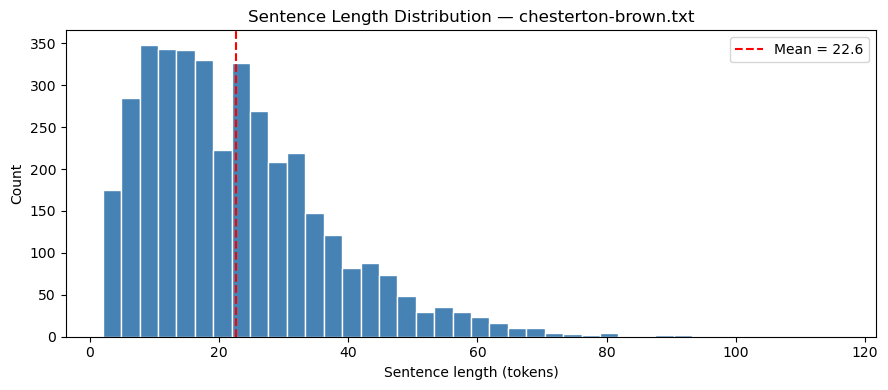

In [ ]:
# Sentence length distribution
sent_lengths = [len(s) for s in all_sents]

plt.figure(figsize=(9, 4))
plt.hist(sent_lengths, bins=40, color='steelblue', edgecolor='white')
plt.axvline(x=sum(sent_lengths)/len(sent_lengths), color='red',
            linestyle='--', label=f'Mean = {sum(sent_lengths)/len(sent_lengths):.1f}')
plt.xlabel('Sentence length (tokens)')
plt.ylabel('Count')
plt.title(f'Sentence Length Distribution — {TEXT_ID}')
plt.legend()
plt.tight_layout()
plt.show()

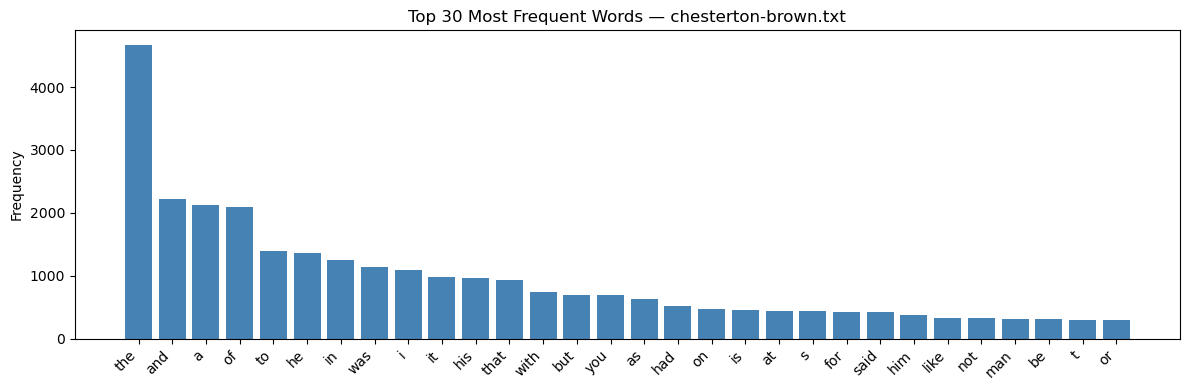

In [ ]:
# Top-30 most frequent words (excluding punctuation)
all_tokens = [w.lower() for w in gutenberg.words(TEXT_ID) if w.isalpha()]
freq = collections.Counter(all_tokens)

top_words, top_counts = zip(*freq.most_common(30))

plt.figure(figsize=(12, 4))
plt.bar(top_words, top_counts, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Frequency')
plt.title(f'Top 30 Most Frequent Words — {TEXT_ID}')
plt.tight_layout()
plt.show()

---
## 4. Preprocessing

In [ ]:
def preprocess_sents(sentences):
    """Lowercase every token in every sentence."""
    return [[w.lower() for w in sent] for sent in sentences]

# Train / test split (80 / 20)
split = int(0.8 * len(all_sents))
train_sents = preprocess_sents(all_sents[:split])
test_sents  = preprocess_sents(all_sents[split:])

print(f'Training sentences : {len(train_sents):,}')
print(f'Test sentences     : {len(test_sents):,}')
print()
print('Example training sentence:')
print(train_sents[5])

Training sentences : 3,044
Test sentences     : 762

Example training sentence:
['it', 'must', 'not', 'be', 'supposed', 'that', 'dr', 'hood', "'", 's', 'apartments', 'excluded', 'luxury', ',', 'or', 'even', 'poetry', '.']


---
## 5. Build N-gram Models


In [ ]:
# ── Configuration: choose the n values you want to compare ────────────────────
N_VALUES = [1, 2, 3, 4]   # <-- feel free to add 5, 6, ...
# ──────────────────────────────────────────────────────────────────────────────

mle_models = {}   # n -> trained MLE model

for n in N_VALUES:
    train_data, padded_vocab = padded_everygram_pipeline(n, train_sents)
    model = MLE(n)
    model.fit(train_data, padded_vocab)
    mle_models[n] = model
    print(f'n={n}  |  vocab size: {len(model.vocab):,}')

print('\nAll MLE models trained.')

n=1  |  vocab size: 6,959
n=2  |  vocab size: 6,961
n=3  |  vocab size: 6,961
n=4  |  vocab size: 6,961

All MLE models trained.


### 5.1 Inspect Individual Probabilities


In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────
TARGET_WORD = 'father'   # <-- word whose probability we want to inspect
CONTEXT = ('the',)       # <-- context (a tuple of preceding words)
# ──────────────────────────────────────────────────────────────────────────────

print(f"P('{TARGET_WORD}' | context)\n")
for n, model in mle_models.items():
    ctx = CONTEXT[-(n-1):] if n > 1 else []  # trim context to model order
    prob = model.score(TARGET_WORD, ctx)
    print(f'  n={n}, context={list(ctx) if ctx else "(none)"}  ->  P = {prob:.6f}')

P('father' | context)

  n=1, context=(none)  ->  P = 0.002739
  n=2, context=['the']  ->  P = 0.000790
  n=3, context=['the']  ->  P = 0.000790
  n=4, context=['the']  ->  P = 0.000790


---
## 6. Text Generation

In [ ]:
def generate_text(model, num_words=40, text_seed=None, random_seed=RANDOM_SEED):
    """Generate a sentence from an NLTK n-gram model.

    Parameters
    ----------
    model       : trained NLTK language model
    num_words   : maximum number of tokens to generate
    text_seed   : optional list of seed tokens
    random_seed : integer seed for reproducibility
    """
    tokens = model.generate(num_words, text_seed=text_seed, random_seed=random_seed)
    # Keep only content tokens (drop padding markers)
    content = [t for t in tokens if t not in ('<s>', '</s>')]
    return ' '.join(content)


# ── Configuration ─────────────────────────────────────────────────────────────
SEED_WORD   = ["her", "mask"]   # starting word(s) as a list, e.g. ['the'] — or None for free generation. use lower case!
GEN_LENGTH  = 30     # how many tokens to generate
# ──────────────────────────────────────────────────────────────────────────────

print('Generated text for each n-gram order')
print('=' * 70)
for n, model in mle_models.items():
    seed = [SEED_WORD] if isinstance(SEED_WORD, str) else SEED_WORD
    text = generate_text(model, num_words=GEN_LENGTH, text_seed=seed)
    label = {1: 'Unigram', 2: 'Bigram', 3: 'Trigram', 4: '4-gram'}.get(n, f'{n}-gram')
    print(f'\n[{label}]')
    print(text)

Generated text for each n-gram order

[Unigram]
of ' brown anybody see peering to - handsome ', and in ' and on large announced morbid the " that race down a when domestic -- . the nature

[Bigram]
fell , been consulted by the time , from a family curse , and screaming in black hedge he ' t support , and whispering , and as this occasion

[Trigram]
fell , and for the poor young people , but growing thick and healthy ; his dark clothes had nothing to hide ."

[4-gram]
fell , and the priest were still dawdling about the garden on his hands and knees , still looking at the table , and went across to captain cutler and


### 6.1 Interactive Generation — Change the Seed

In [ ]:
# ── Try your own seed ─────────────────────────────────────────────────────────
MY_SEED   = ['the', 'priest']   # <-- change this
MY_N      = 3                   # <-- which model to use
MY_LENGTH = 25                  # <-- how many tokens to generate
# ──────────────────────────────────────────────────────────────────────────────

if MY_N not in mle_models:
    print(f'Model for n={MY_N} not trained. Add {MY_N} to N_VALUES and re-run cell 5.')
else:
    text = generate_text(mle_models[MY_N], num_words=MY_LENGTH, text_seed=MY_SEED)
    print(f'Seed: {MY_SEED}')
    print(f'Generated ({MY_N}-gram): {" ".join(MY_SEED)} {text}')

Seed: ['the', 'priest']
Generated (3-gram): the priest made a mistake .


---
## 7. Perplexity — Quantitative Evaluation


In [ ]:
# Train Laplace-smoothed models for evaluation
laplace_models = {}

for n in N_VALUES:
    train_data, padded_vocab = padded_everygram_pipeline(n, train_sents)
    model = Laplace(n)
    model.fit(train_data, padded_vocab)
    laplace_models[n] = model

print('Laplace models trained.')

Laplace models trained.


In [ ]:
def compute_perplexity(model, n, sentences, max_sents=200):
    """Compute average per-sentence perplexity on a list of tokenised sentences.

    Parameters
    ----------
    model     : trained NLTK language model with .perplexity()
    n         : order of the model
    sentences : list of tokenised sentences (list of lists)
    max_sents : cap the number of sentences to keep computation fast
    """
    perplexities = []
    for sent in sentences[:max_sents]:
        test_ngrams = list(ngrams(list(pad_both_ends(sent, n=n)), n))
        if not test_ngrams:
            continue
        pp = model.perplexity(test_ngrams)
        if math.isfinite(pp):
            perplexities.append(pp)
    return sum(perplexities) / len(perplexities) if perplexities else float('nan')


print(f"{'n':>4}  {'Model':12}  {'Train PP':>10}  {'Test PP':>10}")
print('-' * 44)

train_pps, test_pps = [], []

for n in N_VALUES:
    model = laplace_models[n]
    train_pp = compute_perplexity(model, n, train_sents)
    test_pp  = compute_perplexity(model, n, test_sents)
    train_pps.append(train_pp)
    test_pps.append(test_pp)
    label = {1: 'Unigram', 2: 'Bigram', 3: 'Trigram', 4: '4-gram'}.get(n, f'{n}-gram')
    print(f'{n:>4}  {label:12}  {train_pp:>10.2f}  {test_pp:>10.2f}')

   n  Model           Train PP     Test PP
--------------------------------------------
   1  Unigram           615.35      668.00
   2  Bigram            958.26     1303.75
   3  Trigram          1863.34     2879.58
   4  4-gram           2114.31     3441.21


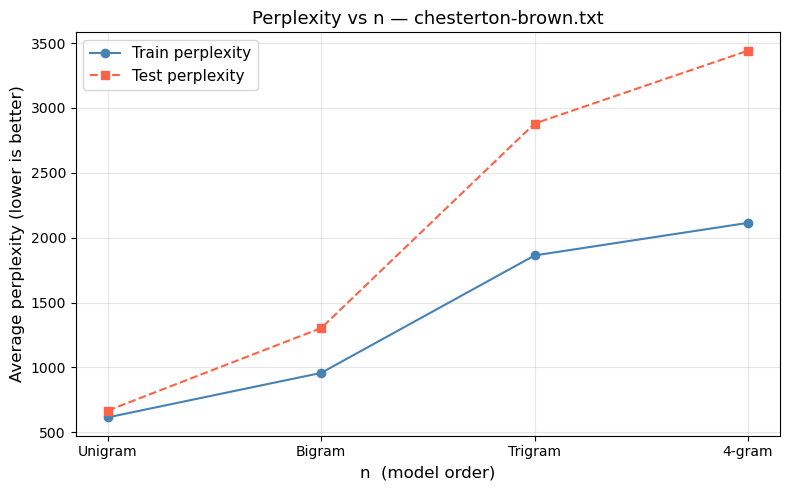

In [ ]:
# Plot perplexity vs n
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(N_VALUES, train_pps, 'o-', label='Train perplexity', color='steelblue')
ax.plot(N_VALUES, test_pps,  's--', label='Test perplexity',  color='tomato')
ax.set_xlabel('n  (model order)', fontsize=12)
ax.set_ylabel('Average perplexity (lower is better)', fontsize=12)
ax.set_title(f'Perplexity vs n — {TEXT_ID}', fontsize=13)
ax.set_xticks(N_VALUES)
ax.set_xticklabels(
    [{1:'Unigram',2:'Bigram',3:'Trigram',4:'4-gram'}.get(n, f'{n}-gram') for n in N_VALUES]
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. Exploring Data Sparsity

   n    Test n-grams    Unseen    % unseen
--------------------------------------------
   1           4,242       282        6.6%
   2           4,442     1,842       41.5%
   3           4,642     3,290       70.9%
   4           4,842     3,957       81.7%


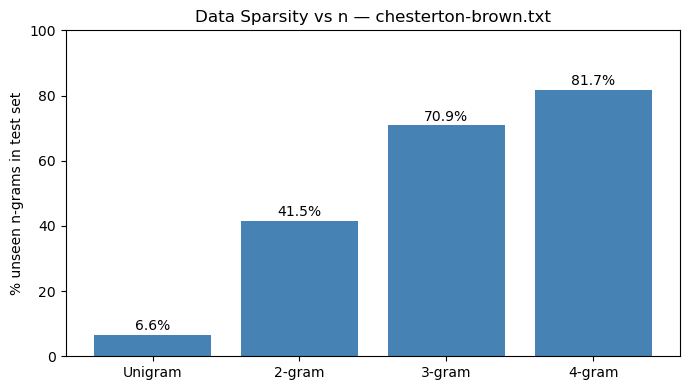

In [ ]:
print(f"{'n':>4}  {'Test n-grams':>14}  {'Unseen':>8}  {'% unseen':>10}")
print('-' * 44)

unseen_fractions = []

for n in N_VALUES:
    model = mle_models[n]   # use MLE to expose zero-probability n-grams clearly
    total, unseen = 0, 0
    for sent in test_sents[:200]:
        for gram in ngrams(list(pad_both_ends(sent, n=n)), n):
            total += 1
            if model.score(gram[-1], gram[:-1]) == 0:
                unseen += 1
    fraction = unseen / total if total else 0
    unseen_fractions.append(fraction * 100)
    print(f'{n:>4}  {total:>14,}  {unseen:>8,}  {fraction*100:>9.1f}%')

# Bar chart
plt.figure(figsize=(7, 4))
bars = plt.bar(
    [f'{n}-gram' if n > 1 else 'Unigram' for n in N_VALUES],
    unseen_fractions, color='steelblue'
)
for bar, val in zip(bars, unseen_fractions):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
plt.ylabel('% unseen n-grams in test set')
plt.title(f'Data Sparsity vs n — {TEXT_ID}')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

---
## Exercises

### Exercise 1 — Effect of N on Text Quality

1. In section 5.1: What do you notice in the individual probabilities? Explain why we are getting these probabilities for different n-gram models.
2. Set `SEED_WORD = None` in Section 6 and generate 50 tokens for each n = 1, 2, 3, 4.
3. Read the generated texts. Which model produces the most coherent output? Which the least?
4. Now try `SEED_WORD = 'the'`. How does having a seed change things for each model?

**Observations**

For this exercise, chesterton-brown.txt is used.

1.
The given setup of the target word being "father" and context "the" is used, the code and results are repeated in the first code cell below. The first thing to notice in the individual probabilties is that the individual probability of n=1, is significantly higher than for n=2,3,4 and that the probabilities of n=2,3,4 is equal. The high individual probability of n=1, is because the unigram model ignores the context and is simply printing the overall frequency of the target word in the text. The other models takes the given context into account and estimates how often the target word appears after 1, 2 or 3 of the previous words, but since the context is merely the word "the", considering more than 1 of the previous words does not make a difference. For a longer context, these values would therefore differ.

2.
The code of section 6 is copied and changed to SEED_WORD=None, see exercise 1.2 below. 50 tokes is then generated for each n=1, 2, 3, 4. See results of exercise 1.2 in the code cells below.

3.
The bigram model seems to produce the most coherent longer output capturing some word to word dependencies and recognizable phrases. The unigram is the least coherent because it ignores context and simply samples words according to their overall frequencies. The trigram and 4-gram models also produce locally coherent phrases but they end very quickly, which makes them less usefull for evaluating long terms coherence.

4.
See exercise 1.4 below for implementation. Having a seed does not change anything for the unigram model, it is the exact same text. For the bigram model, only a single word, the first word, is changed from nightmare to poet! which is also a rather small change, only slighly improving the coherence of the sentence. It does, however change a lot for the trigram and 4-gram models which both improve significantly.


In [ ]:
# Exercise 1.1
print(f"P('{TARGET_WORD}' | context)\n")
for n, model in mle_models.items():
    ctx = CONTEXT[-(n-1):] if n > 1 else []  # trim context to model order
    prob = model.score(TARGET_WORD, ctx)
    print(f'  n={n}, context={list(ctx) if ctx else "(none)"}  ->  P = {prob:.6f}')

P('father' | context)

  n=1, context=(none)  ->  P = 0.002739
  n=2, context=['the']  ->  P = 0.000790
  n=3, context=['the']  ->  P = 0.000790
  n=4, context=['the']  ->  P = 0.000790


In [ ]:
# Exercise 1.2
# ── Configuration ─────────────────────────────────────────────────────────────
SEED_WORD = None   # starting word(s) as a list, e.g. ['the'] — or None for free generation. use lower case!
GEN_LENGTH  = 50     # how many tokens to generate
# ──────────────────────────────────────────────────────────────────────────────

print('Generated text for each n-gram order')
print('=' * 70)
for n, model in mle_models.items():
    seed = [SEED_WORD] if isinstance(SEED_WORD, str) else SEED_WORD
    text = generate_text(model, num_words=GEN_LENGTH, text_seed=seed)
    label = {1: 'Unigram', 2: 'Bigram', 3: 'Trigram', 4: '4-gram'}.get(n, f'{n}-gram')
    print(f'\n[{label}]')
    print(text)

Generated text for each n-gram order

[Unigram]
of ' brown anybody see peering to - handsome ', and in ' and on large announced morbid the " that race down a when domestic -- . the nature that saw jacket with first life the occupants the may red , aristocrat call ," as . but of fact

[Bigram]
nightmare . a shade of these black eyes , and more , and screaming in black hedge he ' t support , and whispering , and as this occasion ; it like very like don ' s tale as such a fellow , after a child , nothing but

[Trigram]
marie antoinette .

[4-gram]
land , and over the top of swagger .


In [ ]:
# Exercise 1.4
# ── Configuration ─────────────────────────────────────────────────────────────
SEED_WORD = ['the']   # starting word(s) as a list, e.g. ['the'] — or None for free generation. use lower case!
GEN_LENGTH  = 50     # how many tokens to generate
# ──────────────────────────────────────────────────────────────────────────────

print('Generated text for each n-gram order')
print('=' * 70)
for n, model in mle_models.items():
    seed = [SEED_WORD] if isinstance(SEED_WORD, str) else SEED_WORD
    text = generate_text(model, num_words=GEN_LENGTH, text_seed=seed)
    label = {1: 'Unigram', 2: 'Bigram', 3: 'Trigram', 4: '4-gram'}.get(n, f'{n}-gram')
    print(f'\n[{label}]')
    print(text)

Generated text for each n-gram order

[Unigram]
of ' brown anybody see peering to - handsome ', and in ' and on large announced morbid the " that race down a when domestic -- . the nature that saw jacket with first life the occupants the may red , aristocrat call ," as . but of fact

[Bigram]
poet ! a shade of these black eyes , and more , and screaming in black hedge he ' t support , and whispering , and as this occasion ; it like very like don ' s tale as such a fellow , after a child , nothing but

[Trigram]
poet ' s daughter will be till god sends us braver men .

[4-gram]
poet ' s head like a purple windmill a thing happened which was superficially even more startling .


---

### Exercise 2 — Comparing Texts

1. Repeat the full analysis (Sections 4–8) with **two different texts** from the Gutenberg corpus (e.g. `carroll-alice.txt` and `shakespeare-hamlet.txt`).
2. For both texts, record the test perplexity for n = 1, 2, 3, 4 (Laplace model).
3. Which text gives lower perplexity at each n? Why might that be?

| n | Alice PP | Hamlet PP |
|---|----------|-----------|
| 1 | 458.14 | 596.70 |
| 2 | 471.27 | 884.19 |
| 3 | 870.47 | 1522.95 |
| 4 | 1078.29 | 1745.59 |

**Analysis**

The analysis is performed with both carroll-alice.txt and shakespeare-hamlet.txt. The resulting perplexity is calculated in the code cells below and shown in the table above.

The Alice model gives lower text perplexity than the Hamlet model for every value of n. This means that with the Laplace smoothed n-gram models, the test portion of the Alice test is generally easier to predict for the model than the test portion of Hamlet. This is most likely because the Alice text has a more regular and repetivie pose with simpler sentence structure and vocabulary than the Hamlet text. Shakespear is known for his unique language, which is quite likely a contributor. 

The reason the perplexity tends to increase with n is most likely because of sparsity.

In [ ]:
# Exercise 2.1 -carroll-alice.txt perplexity
print(f"{'n':>4}  {'Model':12}  {'Train PP':>10}  {'Test PP':>10}")
print('-' * 44)

train_pps, test_pps = [], []

for n in N_VALUES:
    model = laplace_models[n]
    train_pp = compute_perplexity(model, n, train_sents)
    test_pp  = compute_perplexity(model, n, test_sents)
    train_pps.append(train_pp)
    test_pps.append(test_pp)
    label = {1: 'Unigram', 2: 'Bigram', 3: 'Trigram', 4: '4-gram'}.get(n, f'{n}-gram')
    print(f'{n:>4}  {label:12}  {train_pp:>10.2f}  {test_pp:>10.2f}')

   n  Model           Train PP     Test PP
--------------------------------------------
   1  Unigram           383.62      458.14
   2  Bigram            348.72      471.27
   3  Trigram           607.00      870.47
   4  4-gram            719.32     1078.29


In [ ]:
# Exercise 2.2 - shakespeare-hamlet perplexity
print(f"{'n':>4}  {'Model':12}  {'Train PP':>10}  {'Test PP':>10}")
print('-' * 44)

train_pps, test_pps = [], []

for n in N_VALUES:
    model = laplace_models[n]
    train_pp = compute_perplexity(model, n, train_sents)
    test_pp  = compute_perplexity(model, n, test_sents)
    train_pps.append(train_pp)
    test_pps.append(test_pp)
    label = {1: 'Unigram', 2: 'Bigram', 3: 'Trigram', 4: '4-gram'}.get(n, f'{n}-gram')
    print(f'{n:>4}  {label:12}  {train_pp:>10.2f}  {test_pp:>10.2f}')

   n  Model           Train PP     Test PP
--------------------------------------------
   1  Unigram           436.01      596.70
   2  Bigram            526.69      884.19
   3  Trigram           827.75     1522.95
   4  4-gram            909.23     1745.59


---

### Exercise 3 — Training Data Size

Data sparsity worsens when training data is small.  
Using your chosen text, train the **trigram Laplace model** on three different-sized training sets>
* 10% of sentences  
* 50% of sentences  
* 80% of sentences  

For each, compute the test perplexity and the % of unseen n-grams. What trend do you observe?

| Training fraction | Test perplexity | % unseen trigrams |
|-------------------|-----------------|-------------------|
| 10% | 4211.08 | 84.3% |
| 50% | 3214.71 | 75.1% |
| 80% | 2879.58 | 70.9% |

**Analysis**

It is generally observed that both the the perplexity and the unseen trigrams decreases with the increase of training data. This is also what would be expected since as the training set becomes larger, the model has seen more trigrams context and therefore suffers less from data sparsity, resulting in a lower perplexity. It should, however, be noted that the above results are for a fixed vocabulary where every model uses the same set of possible words when assigning probabilities. If each model is allowed to build its own vocabulary, the unseen trigrams remains the same, but the results of the test perplexity flips, meaning an increasing trends is instead seen. This occurrs because many test words becomes <UNK> when using a small training set, meaning they are unknown and therefore collapse into one unknown token, making the test set artifically easier. This mainly occurs due to the laplace smoothing. Using a fixed vocabulary then makes the comparison fairer and gives the above results.



In [ ]:
# Exercise 3
TEXT_ID = 'chesterton-brown.txt'
RANDOM_SEED = 42 
N_VALUE=3

all_sents = list(gutenberg.sents(TEXT_ID))

split = int(0.8 * len(all_sents))
train_sents = preprocess_sents(all_sents[:split])
test_sents  = preprocess_sents(all_sents[split:])

from nltk.lm.preprocessing import padded_everygram_pipeline
from nltk.lm import Laplace, MLE

_, fixed_vocab = padded_everygram_pipeline(N_VALUE, train_sents)
fixed_vocab = list(fixed_vocab)  # consume generator once and reuse


Train_fraction=[0.10, 0.50, 0.80]

laplace_models = {}
unseen_fractions = []
mle_models = {}

for frac in Train_fraction:
    train_size=int(frac * len(all_sents))
    train_subset = train_sents[:train_size]
    
    train_data, padded_vocab = padded_everygram_pipeline(N_VALUE, train_subset)
    model = Laplace(N_VALUE)
    model.fit(train_data, fixed_vocab)
    train_pp = compute_perplexity(model, N_VALUE, train_subset)
    test_pp  = compute_perplexity(model, N_VALUE, test_sents)
    train_pps.append(train_pp)
    test_pps.append(test_pp)
    # MLE model for unseen trigram counting
    train_data_mle, padded_vocab_mle = padded_everygram_pipeline(N_VALUE, train_subset)
    mle_model = MLE(N_VALUE)
    mle_model.fit(train_data_mle, fixed_vocab)

    total, unseen = 0, 0

    for sent in test_sents[:200]:
        padded_sent = list(pad_both_ends(sent, n=N_VALUE))

        for gram in ngrams(padded_sent, N_VALUE):
            total += 1

            word = gram[-1]
            context = gram[:-1]

            if mle_model.score(word, context) == 0:
                unseen += 1

    fraction = unseen / total if total else 0
    unseen_fractions.append(fraction * 100)
    print(f"Training fraction={frac:.0%}, sentences={train_size:,}, test PP={test_pp:.2f}, unseen trigrams={fraction*100:.1f}%")


Training fraction=10%, sentences=380, test PP=4211.08, unseen trigrams=84.3%
Training fraction=50%, sentences=1,903, test PP=3214.71, unseen trigrams=75.1%
Training fraction=80%, sentences=3,044, test PP=2879.58, unseen trigrams=70.9%


# L23 Train Your Own GPT Model

## For the SWMAL O3 Journal

### Qa Journaling the hands-on exercise
Large langugage models are changing the way we study, work and get new ideas, but how are these actuallly made? To create a large language model(LLM) one would first of all need so data to train a model, here a H.C. Andersen tale is chosen for this task as a proof of concept, for a LLM to be usable a much larger training set is needed. During traing a few configurations was set starting with the following: max_iters=10, warmup_iters=1, eval_iters=1, eval_interval=1. By training the model a train- and val-loss is output, we got the following: "step 10: train loss 3.0239, val loss 3.0703". Once the model was trained it was tested, by setting the following --out_dir=out-hca --temperature=0.8 --num_samples=2 --start="Der kom en solda", now the model would try to complete the story beginning with "Der kom en solda", but both samples looked like nonsense, here the model didn't even have an idea of what a sentence might look like, combining letter, numbers and other signes, a few lines from sample 1:\
"Der kom en soldaoænu nn t d
iQnir to d nåt de;
rn nen naPn g ., GnlCllten å è t geer d df ­ lg cer th, ste sLnde OnS ginådrs n sr4enn g laut d...".\
So the model definitly needed longer training, the max_iter was set to 1000 iterations, with the loss: step 1000: train loss 1.6151, val loss 1.7868. Once again trying to predict the following words, where the first sample look like: \
"Der kom en soldatter op til
i dig to den kom har. Der lille på hønsen, og åndte gennem de kunne af de, stå så
det var inders noget om deligt brosene, savde sang for døden lyste og hans til syntet.
"Jeg hører jeg være, jeg, nirke!" sagde og han faprinset han. I hvor er man klokkende..."\
After 1000 iterations the model is much better at predicting the words, there isn't much logic in the sentences, but now it prints out actual danish words. Finetuning the model predictions by tuning the temperature to 0.55 would make the predictions better in my humble opinion. And even though changing the n_layer and n_head to something else the validation loss might decrease a bit, but even though the validation loss is lower there isn't more logic in the sentences produced by the models, the most logic predictions was created using n_layer = 3, n_head = 3, n_embd = 192.

### Qb Explain some of the details of LLM training and prediction
Temperature is a hyperparameter used to control the randomness—and by extension, the "creativity"—of the model's output. A LLM doesn't actually pick a word, it calculates a probability distribution for all possible next tokens in its vocabulary, and then choose the one with the highest probability, using a small termperature will give the word with the highest probability an even higher probability, meaning that the model will be very confident since it will just be citing something from the training set, most likely the most used word. For a high temperature the model will be more crative and sometimes not pick the word that with a low termpurature would have had the highest probalility.\
For a LLM the design matrix is a 2D tensor, and the content is just token IDs. To be able to predict the next words each integer in the designmatrix is mapped to vector called the embedding, wich could be considered a logic between the tokens. These tokens can be interpredet as words or more accurately parts of words that the model uses to understand the logic of the sentence.\
The test data is more qualitative instead of being qualitative, here logic is needed to actually see if the model is correct. \
Promting is used to lead the model into the answer so the model knows what to answer or where to continue, in this example using a fairy tale.\

I created my own dataset from chapter 1 of the bible (source: https://www.bibelselskabet.dk/brugbibelen/bibelenonline/1_Mos/1) i trained it on 1000 iterations and got this:\
"I begyndelsen og den kunne sidderop i et store begyndelig og høns fløj og stor
skrækker i løfter og forstankeligt og det skulle var løb ud i var en savn, så var dejligt
var hendes gennem selv til deran for sang og så det kirkere i de som igen. Det var han var det en mandklæder"\
It is not good but it is a proof of concept, that i can control what my LLM actually knows might be useful another time.